In [1]:
import pandas as pd
pd.options.display.max_columns = 999
import numpy as np
import seaborn as sns
import re
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
%matplotlib inline
import plotly.io as pio
pio.renderers.default = 'notebook'

In [2]:
from scipy import stats
from sklearn.metrics import mean_squared_error

In [3]:
from sklearn import model_selection, preprocessing
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import scipy.stats as stats
import seaborn as sns

In [4]:
old_incidents=pd.read_csv("LFB Incident data from 2009 - 2017.xls", sep=',', low_memory=False)
recent_incidents=pd.read_csv("LFB Incident data from 2018 onwards.xls", sep=',', low_memory=False)

In [5]:
incidents=pd.concat([old_incidents, recent_incidents], axis=0) #Concatenate both dataframes

In [6]:
old_mob=pd.read_csv("LFB Mobilisation data from January 2009 - 2014.xls", sep=';', low_memory=False)
middle_mob=pd.read_csv("LFB Mobilisation data from 2015 - 2020.xls", sep=';', low_memory=False)
recent_mob=pd.read_csv("LFB Mobilisation data 2021 - 2024.xls", sep=';', low_memory=False)

In [10]:
mobs=pd.concat([old_mob, middle_mob, recent_mob], axis=0)

In [11]:
mobs_dupes=mobs.groupby('IncidentNumber').size()
print("Duplicates in mob:")
print(mobs_dupes)

Duplicates in mob:
IncidentNumber
1092        1
1111        1
1112        1
1121        2
1131        1
           ..
99989151    1
99992151    2
99995151    2
99998151    1
99999151    1
Length: 1652636, dtype: int64


In [12]:
mobs.infer_datetime_format=True
mobs['DateAndTimeMobilised'] = pd.to_datetime(mobs['DateAndTimeMobilised'], format='mixed', errors='coerce')
mobs['Weekday'] = mobs['DateAndTimeMobilised'].dt.strftime('%A') #get weekday
mobs["Month"] = pd.to_datetime(mobs['DateAndTimeMobilised']).dt.month
mobs["Day_Month"] = pd.to_datetime(mobs['DateAndTimeMobilised']).dt.day
mobs["Incident_Date"]=mobs["DateAndTimeMobilised"].dt.strftime('%Y.%m.%d')
mobs.head(5)

,IncidentNumber,CalYear,HourOfCall,ResourceMobilisationId,Resource_Code,PerformanceReporting,DateAndTimeMobilised,DateAndTimeMobile,DateAndTimeArrived,TurnoutTimeSeconds,TravelTimeSeconds,AttendanceTimeSeconds,DateAndTimeLeft,DateAndTimeReturned,DeployedFromStation_Code,DeployedFromStation_Name,DeployedFromLocation,PumpOrder,PlusCode_Code,PlusCode_Description,DelayCodeId,DelayCode_Description,BoroughName,WardName,Weekday,Month,Day_Month,Incident_Date
0,235138081,2009,0,38426,H271,1,2009-01-01 00:02:00,NaN,01.01.2009 00:07,NaN,NaN,319,01.01.2009 00:16,01.01.2009 00:23,H27,Battersea,Home Station,1,Initial,Initial Mobilisation,NaN,NaN,NaN,NaN,Thursday,1,1,2009.01.01
1,235138081,2009,0,38427,H212,2,2009-01-01 00:02:00,01.01.2009 00:06,01.01.2009 00:08,253.0,89.0,342,01.01.2009 00:12,01.01.2009 00:12,H21,Clapham,Home Station,2,Initial,Initial Mobilisation,NaN,NaN,NaN,NaN,Thursday,1,1,2009.01.01
2,2091,2009,0,38429,A341,1,2009-01-01 00:04:00,01.01.2009 00:06,01.01.2009 00:09,151.0,157.0,308,01.01.2009 00:16,01.01.2009 00:17,A34,Edmonton,Home Station,1,Initial,Initial Mobilisation,NaN,NaN,NaN,NaN,Thursday,1,1,2009.01.01
3,3091,2009,0,38430,G232,1,2009-01-01 00:04:00,01.01.2009 00:06,01.01.2009 00:08,108.0,102.0,210,01.01.2009 00:20,01.01.2009 00:20,G23,Hillingdon,Home Station,1,Initial,Initial Mobilisation,NaN,NaN,NaN,NaN,Thursday,1,1,2009.01.01
4,5091,2009,0,38432,A311,1,2009-01-01 00:06:00,01.01.2009 00:07,01.01.2009 00:09,114.0,119.0,233,01.01.2009 00:11,01.01.2009 00:22,A31,Holloway,Home Station,1,Initial,Initial Mobilisation,NaN,NaN,NaN,NaN,Thursday,1,1,2009.01.01


In [13]:
mobs = mobs.reset_index()

In [14]:
mobs.head()

,index,IncidentNumber,CalYear,HourOfCall,ResourceMobilisationId,Resource_Code,PerformanceReporting,DateAndTimeMobilised,DateAndTimeMobile,DateAndTimeArrived,TurnoutTimeSeconds,TravelTimeSeconds,AttendanceTimeSeconds,DateAndTimeLeft,DateAndTimeReturned,DeployedFromStation_Code,DeployedFromStation_Name,DeployedFromLocation,PumpOrder,PlusCode_Code,PlusCode_Description,DelayCodeId,DelayCode_Description,BoroughName,WardName,Weekday,Month,Day_Month,Incident_Date
0,0,235138081,2009,0,38426,H271,1,2009-01-01 00:02:00,NaN,01.01.2009 00:07,NaN,NaN,319,01.01.2009 00:16,01.01.2009 00:23,H27,Battersea,Home Station,1,Initial,Initial Mobilisation,NaN,NaN,NaN,NaN,Thursday,1,1,2009.01.01
1,1,235138081,2009,0,38427,H212,2,2009-01-01 00:02:00,01.01.2009 00:06,01.01.2009 00:08,253.0,89.0,342,01.01.2009 00:12,01.01.2009 00:12,H21,Clapham,Home Station,2,Initial,Initial Mobilisation,NaN,NaN,NaN,NaN,Thursday,1,1,2009.01.01
2,2,2091,2009,0,38429,A341,1,2009-01-01 00:04:00,01.01.2009 00:06,01.01.2009 00:09,151.0,157.0,308,01.01.2009 00:16,01.01.2009 00:17,A34,Edmonton,Home Station,1,Initial,Initial Mobilisation,NaN,NaN,NaN,NaN,Thursday,1,1,2009.01.01
3,3,3091,2009,0,38430,G232,1,2009-01-01 00:04:00,01.01.2009 00:06,01.01.2009 00:08,108.0,102.0,210,01.01.2009 00:20,01.01.2009 00:20,G23,Hillingdon,Home Station,1,Initial,Initial Mobilisation,NaN,NaN,NaN,NaN,Thursday,1,1,2009.01.01
4,4,5091,2009,0,38432,A311,1,2009-01-01 00:06:00,01.01.2009 00:07,01.01.2009 00:09,114.0,119.0,233,01.01.2009 00:11,01.01.2009 00:22,A31,Holloway,Home Station,1,Initial,Initial Mobilisation,NaN,NaN,NaN,NaN,Thursday,1,1,2009.01.01


In [15]:
mobs['IncidentNumber'].nunique()

1652636

In [16]:
incidents.infer_datetime_format=True
incidents['DateOfCall'] = pd.to_datetime(incidents['DateOfCall'], format='mixed', errors='coerce')
incidents['Weekday'] = incidents['DateOfCall'].dt.strftime('%A') #get weekday
incidents["Month"] = pd.to_datetime(incidents['DateOfCall']).dt.month
incidents["Day_Month"] = pd.to_datetime(incidents['DateOfCall']).dt.day
incidents["Incident_Date"]=incidents["DateOfCall"].dt.strftime('%Y.%m.%d')
incidents.head(5)

,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,AddressQualifier,Postcode_full,Postcode_district,UPRN,USRN,IncGeo_BoroughCode,IncGeo_BoroughName,ProperCase,IncGeo_WardCode,IncGeo_WardName,IncGeo_WardNameNew,Easting_m,Northing_m,Easting_rounded,Northing_rounded,Latitude,Longitude,FRS,IncidentStationGround,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),NumCalls,Weekday,Month,Day_Month,Incident_Date
0,235138081.00,2009-01-01,2009,00:00:37,0,Special Service,Special Service,RTC,Road Vehicle,Car,In street close to gazetteer location,SW11 4LB,SW11,NaN,NaN,E09000032,WANDSWORTH,Wandsworth,E05014010,Battersea Park,Battersea Park,528652.0,176830.0,528650,176850,51.475812,-0.148894,London,Battersea,319.0,Battersea,342.0,Clapham,2.0,2.0,2,60,255,1.0,Thursday,1,1,2009.01.01
1,1091.00,2009-01-01,2009,00:00:46,0,Special Service,Special Service,Assist other agencies,Outdoor,Lake/pond/reservoir,Open land/water - nearest gazetteer location,SE1 7SG,SE1,NaN,NaN,E09000022,LAMBETH,Lambeth,E05014118,Waterloo & South Bank,Waterloo & South Bank,530485.0,179007.0,530450,179050,51.494957,-0.121712,London,Lambeth,NaN,NaN,NaN,NaN,NaN,NaN,1,60,255,1.0,Thursday,1,1,2009.01.01
2,2091.00,2009-01-01,2009,00:03:00,0,Fire,Secondary Fire,NaN,Outdoor,Road surface/pavement,In street outside gazetteer location,N9 9EL,N9,NaN,NaN,E09000010,ENFIELD,Enfield,E05013682,Haselbury,Haselbury,533773.0,194492.0,533750,194450,51.633342,-0.068488,London,Edmonton,308.0,Edmonton,NaN,NaN,1.0,1.0,1,60,255,2.0,Thursday,1,1,2009.01.01
3,3091.00,2009-01-01,2009,00:04:27,0,Fire,Secondary Fire,NaN,Outdoor,Domestic garden (vegetation not equipment),On land associated with building,UB10 0DG,UB10,1.000215e+11,21401491.0,E09000017,HILLINGDON,Hillingdon,E05013571,Hillingdon East,Hillingdon East,507738.0,182805.0,507750,182850,51.533882,-0.448089,London,Hillingdon,210.0,Hillingdon,NaN,NaN,1.0,1.0,1,60,255,2.0,Thursday,1,1,2009.01.01
4,5091.00,2009-01-01,2009,00:05:39,0,Fire,Secondary Fire,NaN,Outdoor,Cycle path/public footpath/bridleway,In street outside gazetteer location,N7 8HG,N7,NaN,NaN,E09000019,ISLINGTON,Islington,E05013708,Laycock,Laycock,531058.0,185307.0,531050,185350,51.551441,-0.111120,London,Holloway,233.0,Holloway,250.0,Holloway,1.0,2.0,2,60,255,1.0,Thursday,1,1,2009.01.01


In [17]:
incidents = incidents.reset_index()

In [20]:
mobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2496800 entries, 0 to 2496799
Data columns (total 29 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   index                     int64         
 1   IncidentNumber            object        
 2   CalYear                   int64         
 3   HourOfCall                int64         
 4   ResourceMobilisationId    int64         
 5   Resource_Code             object        
 6   PerformanceReporting      object        
 7   DateAndTimeMobilised      datetime64[ns]
 8   DateAndTimeMobile         object        
 9   DateAndTimeArrived        object        
 10  TurnoutTimeSeconds        float64       
 11  TravelTimeSeconds         float64       
 12  AttendanceTimeSeconds     int64         
 13  DateAndTimeLeft           object        
 14  DateAndTimeReturned       object        
 15  DeployedFromStation_Code  object        
 16  DeployedFromStation_Name  object        
 17  Deployed

In [21]:
incidents=incidents.drop(['PropertyType', 'IncGeo_BoroughCode', 'IncGeo_BoroughName', 'IncGeo_WardName', 'IncGeo_WardNameNew', 'IncGeo_WardCode', 'Postcode_full', 'Easting_m', 'Northing_m', 'FRS', 'NumCalls', 'UPRN', 'USRN', 'Latitude', 'Longitude'], axis=1) 

In [22]:
mobs=mobs.drop(['WardName', 'PlusCode_Code', 'PlusCode_Description', 'Resource_Code', 'DeployedFromStation_Code', 'DelayCodeId'], axis=1) 

In [23]:
# Ensure "IncidentNumber" column exists in both dataframes
if "IncidentNumber" not in incidents.columns or "IncidentNumber" not in mobs.columns:
    raise KeyError("Missing 'IncidentNumber' column in one of the datasets.")

# Extract unique IncidentNumbers, ensuring all are treated as strings
combined_incident_numbers = (
    pd.concat([incidents["IncidentNumber"], mobs["IncidentNumber"]])
    .dropna()  # Remove NaN values
    .map(str)  # Convert non-null values to string
    .unique()
)

# Function to classify ID formats
def classify_id(incident_number):
    if re.fullmatch(r"\d+", incident_number):  # Pure integer
        return "Integer"
    elif re.fullmatch(r"\d+\.\d+", incident_number):  # Float-like
        return "Float"
    elif re.fullmatch(r"\d+-\d+", incident_number):  # Hyphenated
        return "Hyphenated"
    elif re.fullmatch(r"\d+E\d+", incident_number, re.IGNORECASE):  # Scientific notation
        return "Scientific Notation"
    else:
        return "Other"

# Analyze variations
variations = {category: [] for category in ["Integer", "Float", "Hyphenated", "Scientific Notation", "Other"]}
for num in combined_incident_numbers:
    category = classify_id(num)
    variations[category].append(num)

# Display results
for category, examples in variations.items():
    print(f"{category} ({len(examples)} examples): {examples[:5]}")

Integer (693226 examples): ['235138081', '2091', '3091', '5091', '6091']
Float (768218 examples): ['235138081.00', '1091.00', '2091.00', '3091.00', '5091.00']
Hyphenated (1029771 examples): ['162970-23112015', '160003-17112015', '160002-17112015', '160005-17112015', '160006-17112015']
Scientific Notation (0 examples): []
Other (0 examples): []


In [24]:
# Function to clean and convert IncidentNumber to integer
def clean_incident_number(incident_number):
    incident_number = str(incident_number)  # Ensure it's a string
    if "." in incident_number:  # Convert float-like numbers
        return int(float(incident_number))
    elif "-" in incident_number:  # Remove hyphen and convert to int
        return int(incident_number.replace("-", ""))
    return int(incident_number)  # Directly convert integers

# Apply transformation to both dataframes
incidents["IncidentNumber"] = incidents["IncidentNumber"].dropna().map(clean_incident_number)
mobs["IncidentNumber"] = mobs["IncidentNumber"].dropna().map(clean_incident_number)

# Ensure the column is now int64 type
incidents["IncidentNumber"] = incidents["IncidentNumber"].astype("int64")
incidents["IncidentNumber"] = incidents["IncidentNumber"].astype("int64")

# Confirm transformation
print(incidents["IncidentNumber"].dtype)  # Should print int64
print(incidents["IncidentNumber"].dtype)  # Should print int64

int64
int64


In [25]:
incidents_dupes=incidents.groupby('IncidentNumber').size()
print("Duplicates in incidents:")
print(incidents_dupes)

Duplicates in incidents:
IncidentNumber
1091              1
1092              1
1102              1
1109              1
1111              1
                 ..
22224631122024    1
22224831122024    1
22224931122024    1
22225031122024    1
22225131122024    1
Length: 1793315, dtype: int64


In [27]:
mobs_dupes=mobs.groupby('IncidentNumber').size()
print("Duplicates in mob:")
print(mobs_dupes)

Duplicates in mob:
IncidentNumber
1092              1
1111              1
1112              1
1121              2
1131              1
                 ..
21394931122022    1
21395131122022    1
21395331122022    1
21395431122022    1
21395731122022    1
Length: 1652636, dtype: int64


In [29]:
merged_check = pd.merge(incidents[['IncidentNumber']], mobs[['IncidentNumber']], how='outer', indicator=True)

In [30]:
compatible_rows=merged_check[merged_check['_merge'] == 'both']

In [31]:
compat_mobs=mobs[mobs['IncidentNumber'].isin(compatible_rows['IncidentNumber'])]
compat_incidents=incidents[incidents['IncidentNumber'].isin(compatible_rows['IncidentNumber'])]

In [32]:
merge=pd.merge(compat_mobs, compat_incidents, on=['IncidentNumber', 'Incident_Date'], how='left', suffixes=('_compat_mobs', '_compat_incidents'))

In [34]:
merge.loc[merge["StopCodeDescription"] == "Special Service", "StopCodeDescription"] = merge["SpecialServiceType"]
merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2489019 entries, 0 to 2489018
Data columns (total 50 columns):
 #   Column                                  Dtype         
---  ------                                  -----         
 0   index_compat_mobs                       int64         
 1   IncidentNumber                          int64         
 2   CalYear_compat_mobs                     int64         
 3   HourOfCall_compat_mobs                  int64         
 4   ResourceMobilisationId                  int64         
 5   PerformanceReporting                    object        
 6   DateAndTimeMobilised                    datetime64[ns]
 7   DateAndTimeMobile                       object        
 8   DateAndTimeArrived                      object        
 9   TurnoutTimeSeconds                      float64       
 10  TravelTimeSeconds                       float64       
 11  AttendanceTimeSeconds                   int64         
 12  DateAndTimeLeft                         ob

In [35]:
merge.drop('SpecialServiceType', axis=1)

,index_compat_mobs,IncidentNumber,CalYear_compat_mobs,HourOfCall_compat_mobs,ResourceMobilisationId,PerformanceReporting,DateAndTimeMobilised,DateAndTimeMobile,DateAndTimeArrived,TurnoutTimeSeconds,TravelTimeSeconds,AttendanceTimeSeconds,DateAndTimeLeft,DateAndTimeReturned,DeployedFromStation_Name,DeployedFromLocation,PumpOrder,DelayCode_Description,BoroughName,Weekday_compat_mobs,Month_compat_mobs,Day_Month_compat_mobs,Incident_Date,index_compat_incidents,DateOfCall,CalYear_compat_incidents,TimeOfCall,HourOfCall_compat_incidents,IncidentGroup,StopCodeDescription,PropertyCategory,AddressQualifier,Postcode_district,ProperCase,Easting_rounded,Northing_rounded,IncidentStationGround,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),Weekday_compat_incidents,Month_compat_incidents,Day_Month_compat_incidents
0,0,235138081,2009,0,38426,1,2009-01-01 00:02:00,NaN,01.01.2009 00:07,NaN,NaN,319,01.01.2009 00:16,01.01.2009 00:23,Battersea,Home Station,1,NaN,NaN,Thursday,1,1,2009.01.01,0.0,2009-01-01,2009.0,00:00:37,0.0,Special Service,RTC,Road Vehicle,In street close to gazetteer location,SW11,Wandsworth,528650.0,176850.0,Battersea,319.0,Battersea,342.0,Clapham,2.0,2.0,2.0,60.0,255.0,Thursday,1.0,1.0
1,1,235138081,2009,0,38427,2,2009-01-01 00:02:00,01.01.2009 00:06,01.01.2009 00:08,253.0,89.0,342,01.01.2009 00:12,01.01.2009 00:12,Clapham,Home Station,2,NaN,NaN,Thursday,1,1,2009.01.01,0.0,2009-01-01,2009.0,00:00:37,0.0,Special Service,RTC,Road Vehicle,In street close to gazetteer location,SW11,Wandsworth,528650.0,176850.0,Battersea,319.0,Battersea,342.0,Clapham,2.0,2.0,2.0,60.0,255.0,Thursday,1.0,1.0
2,2,2091,2009,0,38429,1,2009-01-01 00:04:00,01.01.2009 00:06,01.01.2009 00:09,151.0,157.0,308,01.01.2009 00:16,01.01.2009 00:17,Edmonton,Home Station,1,NaN,NaN,Thursday,1,1,2009.01.01,2.0,2009-01-01,2009.0,00:03:00,0.0,Fire,Secondary Fire,Outdoor,In street outside gazetteer location,N9,Enfield,533750.0,194450.0,Edmonton,308.0,Edmonton,NaN,NaN,1.0,1.0,1.0,60.0,255.0,Thursday,1.0,1.0
3,3,3091,2009,0,38430,1,2009-01-01 00:04:00,01.01.2009 00:06,01.01.2009 00:08,108.0,102.0,210,01.01.2009 00:20,01.01.2009 00:20,Hillingdon,Home Station,1,NaN,NaN,Thursday,1,1,2009.01.01,3.0,2009-01-01,2009.0,00:04:27,0.0,Fire,Secondary Fire,Outdoor,On land associated with building,UB10,Hillingdon,507750.0,182850.0,Hillingdon,210.0,Hillingdon,NaN,NaN,1.0,1.0,1.0,60.0,255.0,Thursday,1.0,1.0
4,4,5091,2009,0,38432,1,2009-01-01 00:06:00,01.01.2009 00:07,01.01.2009 00:09,114.0,119.0,233,01.01.2009 00:11,01.01.2009 00:22,Holloway,Home Station,1,NaN,NaN,Thursday,1,1,2009.01.01,4.0,2009-01-01,2009.0,00:05:39,0.0,Fire,Secondary Fire,Outdoor,In street outside gazetteer location,N7,Islington,531050.0,185350.0,Holloway,233.0,Holloway,250.0,Holloway,1.0,2.0,2.0,60.0,255.0,Thursday,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2489014,711366,20324029112024,2024,23,6837328,2,2024-11-29 23:28:00,29.11.2024 23:30,29.11.2024 23:36,110.0,379.0,489,29.11.2024 23:40,NaN,Southall,Home Station,2,Not held up,EALING,Friday,11,29,2024.11.29,793894.0,2024-11-29,2024.0,23:28:44,23.0,False Alarm,AFA,Dwelling,Correct incident location,W7,Ealing,515750.0,181650.0,Ealing,401.0,Ealing,489.0,Southall,2.0,2.0,2.0,60.0,430.0,Friday,11.0,29.0
2489015,711367,20324129112024,2024,23,6837329,1,2024-11-29 23:29:00,29.11.2024 23:30,29.11.2024 23:34,69.0,246.0,315,29.11.2024 23:56,NaN,West Norwood,Home Station,1,NaN,LAMBETH,Friday,11,29,2024.11.29,793895.0,2024-11-29,2024.0,23:29:25,23.0,Special Service,Assist other agencies,Dwelling,Within same building,SE27,Lambeth,531350.0,172050.0,West Norwood,315.0,West Norwood,NaN,NaN,1.0,1.0,1.0,60.0,430.0,Friday,11.0,29.0
2489

In [36]:
merge.infer_datetime_format=True
merge['DateAndTimeMobilised'] = pd.to_datetime(merge['DateAndTimeMobilised'],errors='coerce')
merge["Day"] = pd.to_datetime(merge['DateAndTimeMobilised']).dt.day
merge.head(5)

,index_compat_mobs,IncidentNumber,CalYear_compat_mobs,HourOfCall_compat_mobs,ResourceMobilisationId,PerformanceReporting,DateAndTimeMobilised,DateAndTimeMobile,DateAndTimeArrived,TurnoutTimeSeconds,TravelTimeSeconds,AttendanceTimeSeconds,DateAndTimeLeft,DateAndTimeReturned,DeployedFromStation_Name,DeployedFromLocation,PumpOrder,DelayCode_Description,BoroughName,Weekday_compat_mobs,Month_compat_mobs,Day_Month_compat_mobs,Incident_Date,index_compat_incidents,DateOfCall,CalYear_compat_incidents,TimeOfCall,HourOfCall_compat_incidents,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,AddressQualifier,Postcode_district,ProperCase,Easting_rounded,Northing_rounded,IncidentStationGround,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),Weekday_compat_incidents,Month_compat_incidents,Day_Month_compat_incidents,Day
0,0,235138081,2009,0,38426,1,2009-01-01 00:02:00,NaN,01.01.2009 00:07,NaN,NaN,319,01.01.2009 00:16,01.01.2009 00:23,Battersea,Home Station,1,NaN,NaN,Thursday,1,1,2009.01.01,0.0,2009-01-01,2009.0,00:00:37,0.0,Special Service,RTC,RTC,Road Vehicle,In street close to gazetteer location,SW11,Wandsworth,528650.0,176850.0,Battersea,319.0,Battersea,342.0,Clapham,2.0,2.0,2.0,60.0,255.0,Thursday,1.0,1.0,1
1,1,235138081,2009,0,38427,2,2009-01-01 00:02:00,01.01.2009 00:06,01.01.2009 00:08,253.0,89.0,342,01.01.2009 00:12,01.01.2009 00:12,Clapham,Home Station,2,NaN,NaN,Thursday,1,1,2009.01.01,0.0,2009-01-01,2009.0,00:00:37,0.0,Special Service,RTC,RTC,Road Vehicle,In street close to gazetteer location,SW11,Wandsworth,528650.0,176850.0,Battersea,319.0,Battersea,342.0,Clapham,2.0,2.0,2.0,60.0,255.0,Thursday,1.0,1.0,1
2,2,2091,2009,0,38429,1,2009-01-01 00:04:00,01.01.2009 00:06,01.01.2009 00:09,151.0,157.0,308,01.01.2009 00:16,01.01.2009 00:17,Edmonton,Home Station,1,NaN,NaN,Thursday,1,1,2009.01.01,2.0,2009-01-01,2009.0,00:03:00,0.0,Fire,Secondary Fire,NaN,Outdoor,In street outside gazetteer location,N9,Enfield,533750.0,194450.0,Edmonton,308.0,Edmonton,NaN,NaN,1.0,1.0,1.0,60.0,255.0,Thursday,1.0,1.0,1
3,3,3091,2009,0,38430,1,2009-01-01 00:04:00,01.01.2009 00:06,01.01.2009 00:08,108.0,102.0,210,01.01.2009 00:20,01.01.2009 00:20,Hillingdon,Home Station,1,NaN,NaN,Thursday,1,1,2009.01.01,3.0,2009-01-01,2009.0,00:04:27,0.0,Fire,Secondary Fire,NaN,Outdoor,On land associated with building,UB10,Hillingdon,507750.0,182850.0,Hillingdon,210.0,Hillingdon,NaN,NaN,1.0,1.0,1.0,60.0,255.0,Thursday,1.0,1.0,1
4,4,5091,2009,0,38432,1,2009-01-01 00:06:00,01.01.2009 00:07,01.01.2009 00:09,114.0,119.0,233,01.01.2009 00:11,01.01.2009 00:22,Holloway,Home Station,1,NaN,NaN,Thursday,1,1,2009.01.01,4.0,2009-01-01,2009.0,00:05:39,0.0,Fire,Secondary Fire,NaN,Outdoor,In street outside gazetteer location,N7,Islington,531050.0,185350.0,Holloway,233.0,Holloway,250.0,Holloway,1.0,2.0,2.0,60.0,255.0,Thursday,1.0,1.0,1


In [38]:
roadworks=mobs[mobs['DelayCode_Description']=='Traffic, roadworks, etc']
calm=mobs[mobs['DelayCode_Description']=='Traffic calming measures']
address=mobs[mobs['DelayCode_Description']=='Address incomplete/wrong']
smooth=mobs[mobs['DelayCode_Description']=='Not held up']
radio=mobs[mobs['DelayCode_Description']=='Mob/Radio problems when mobilised']
outside_duty=mobs[mobs['DelayCode_Description']=='on outside duty when mobilised']
weather=mobs[mobs['DelayCode_Description']=='Weather conditions']
equipment=mobs[mobs['DelayCode_Description']=='Appliance/Equipment defect']
drills=mobs[mobs['DelayCode_Description']=='At drills when mobilised']

In [49]:
#normalised freq of delay categories
delay_probs = {
    'not held up': 0.596653, 
    'Traffic, roadworks, etc': 0.196955, 
    'Traffic calming measures': 0.063277, 
    'Address_incomplete/wrong': 0.058973, 
    'Mob/Radio problems when mobilised': 0.016130, 
    'Weather conditions': 0.011711, 
    'Appliance/Equipment defect': 0.005109, 
    'At drills when mobilised': 0.004535
}
#define conditional ranges for imputing 'delay'
conditions = [
    (merge['TravelTimeSeconds']>=414.854708 - 2*143.561411) & (merge['TravelTimeSeconds']<= 414.854708 + 2*143.561411), 
    (merge['TravelTimeSeconds']>=429.983637 - 2*144.574693) & (merge['TravelTimeSeconds']<=429.983637 + 2*144.574693),
    (merge['TravelTimeSeconds']>=410.400123 - 2*137.4) & (merge['TravelTimeSeconds']<=410.400123 + 2*137.4),
    (merge['AttendanceTimeSeconds']>=592.248863 - 2*198.36) & (merge['AttendanceTimeSeconds']<=592.248863 + 2*198.36),
    (merge['TurnoutTimeSeconds']>=131.165750 - 2*105.6) & (merge['TurnoutTimeSeconds']<=131.165750 + 2*105.6),
    (merge['AttendanceTimeSeconds']>=525.023118 - 2*156.37) & (merge['AttendanceTimeSeconds']<=525.023118 + 2*156.37),
    (merge['TurnoutTimeSeconds']>=111.218881 - 2*81.97) &  (merge['TurnoutTimeSeconds']<=111.218881 + 2*81.97),
    (merge['TurnoutTimeSeconds']>=107.087066 - 2*73.57) & (merge['TurnoutTimeSeconds']<=107.087066 + 2*73.57)
]

choices = ['not held up', 'Traffic, roadworks, etc', 'Traffic calming measures', 'Address_incomplete/wrong', 'Mob/Radio problems when mobilised', 'Weather conditions', 'Appliance/Equipment defect', 'At drills when mobilised']
probabilities = np.array([delay_probs[choice] for choice in choices])
probabilities /= probabilities.sum()

#conditional imputing
def conditional_impute(row):
    try:
        if pd.isna(row['DelayCode_Description']):
            condition_met = False
        #get the range index for the current travel_time ranges and probabilities
            for idx, condition in enumerate(conditions):
                if condition[row.name]: #check if condition met
                #randomly assign a delay value based on predefined probabilities.
                    row['DelayCode_Description'] = np.random.choice(choices, p=probabilities)
                    condition_met=True
                    break
                if not condition_met:
                    row['DelayCode_Description'] = np.nan                
        return row['DelayCode_Description']
    except Exception as e:
        print(f"Error processing row with travel_time {row['TravelTimeSeconds']}: {e}")
    
#Apply function to dataframe
merge['DelayCode_Description'] = merge.apply(conditional_impute, axis = 1)

print(merge.head())

   index_compat_mobs  IncidentNumber  CalYear_compat_mobs  \
0                  0       235138081                 2009   
1                  1       235138081                 2009   
2                  2            2091                 2009   
3                  3            3091                 2009   
4                  4            5091                 2009   

   HourOfCall_compat_mobs  ResourceMobilisationId PerformanceReporting  \
0                       0                   38426                    1   
1                       0                   38427                    2   
2                       0                   38429                    1   
3                       0                   38430                    1   
4                       0                   38432                    1   

  DateAndTimeMobilised DateAndTimeMobile DateAndTimeArrived  \
0  2009-01-01 00:02:00               NaN   01.01.2009 00:07   
1  2009-01-01 00:02:00  01.01.2009 00:06   01.01.2009 00:08   

In [54]:
merge=merge.drop(['SpecialServiceType', 'BoroughName', 'DateAndTimeReturned'], axis=1)

In [55]:
columns_to_fill=['FirstPumpArriving_AttendanceTime', 'SecondPumpArriving_AttendanceTime', 'SecondPumpArriving_DeployedFromStation']
merge[columns_to_fill]=merge[columns_to_fill].fillna(-1)

In [59]:
merge.shape

(2489019, 48)

In [60]:
dmerge=merge.copy()

In [61]:
clean_merge=merge.dropna()

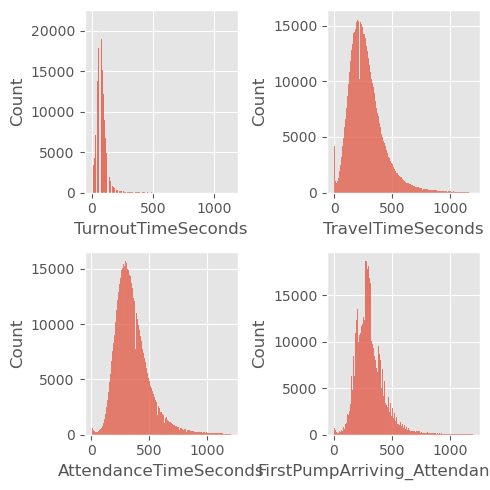

In [63]:
sns.color_palette("crest", as_cmap=True)
fig, axs = plt.subplots(2,2, figsize=(5,5))
sns.histplot(clean_merge.TurnoutTimeSeconds, ax=axs[0,0])
sns.histplot(clean_merge.TravelTimeSeconds, ax=axs[0,1])
sns.histplot(clean_merge.AttendanceTimeSeconds, ax=axs[1,0])
sns.histplot(clean_merge.FirstPumpArriving_AttendanceTime, ax=axs[1,1])
plt.tight_layout()
plt.show()

In [64]:
clean_merge_tot_zero=clean_merge[clean_merge['TurnoutTimeSeconds']==0]
clean_merge_tot_zero.head()
clean_merge_tot_zero.describe()
clean_merge['TurnoutTimeSeconds']=clean_merge['TurnoutTimeSeconds'].replace(0, clean_merge['TurnoutTimeSeconds'].mean())

C:\Users\Thesa\AppData\Local\Temp\ipykernel_7796\3837851636.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [65]:
clean_merge_tot_10=clean_merge[clean_merge['TurnoutTimeSeconds']<=10]
clean_merge_tot_10.describe()

,index_compat_mobs,IncidentNumber,CalYear_compat_mobs,HourOfCall_compat_mobs,ResourceMobilisationId,DateAndTimeMobilised,TurnoutTimeSeconds,TravelTimeSeconds,AttendanceTimeSeconds,PumpOrder,Month_compat_mobs,Day_Month_compat_mobs,index_compat_incidents,DateOfCall,CalYear_compat_incidents,HourOfCall_compat_incidents,Easting_rounded,Northing_rounded,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),Month_compat_incidents,Day_Month_compat_incidents,Day
count,26266.000000,2.626600e+04,26266.000000,26266.000000,2.626600e+04,26266,26266.000000,26266.000000,26266.000000,26266.000000,26266.000000,26266.000000,26266.000000,26266,26266.000000,26266.000000,26266.000000,26266.000000,26266.000000,26266.000000,26266.00000,26266.000000,26266.000000,26266.000000,26266.000000,26266.000000,26266.000000,26266.000000
mean,438273.590916,3.752024e+12,2015.131691,14.153621,4.622149e+06,2015-08-31 13:37:46.508794880,6.214117,264.963146,271.177263,1.182632,6.734904,20.978185,438525.282038,2015-08-30 23:35:49.364197120,2015.131691,14.153621,530225.519683,180659.076372,265.512450,83.017818,1.24823,1.419706,1.480736,78.807432,411.497297,6.734904,20.978185,20.978185
min,113.000000,4.123000e+03,2009.000000,0.000000,4.763200e+04,2009-01-13 23:16:00,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,221.000000,2009-01-13 00:00:00,2009.000000,0.000000,504050.000000,157250.000000,1.000000,-1.000000,1.00000,1.000000,1.000000,60.000000,255.000000,1.000000,1.000000,1.000000
25%,238118.250000,8.021615e+07,2011.000000,12.000000,3.695600e+06,2011-05-24 16:12:15,4.000000,126.000000,132.000000,1.000000,4.000000,16.000000,247639.500000,2011-05-24 00:00:00,2011.000000,12.000000,525250.000000,176750.000000,135.000000,-1.000000,1.00000,1.000000,1.000000,60.000000,260.000000,4.000000,16.000000,16.000000
50%,429996.000000,1.545721e+08,2013.000000,14.000000,4.213830e+06,2013-11-18 04:46:00,6.000000,242.000000,248.000000,1.000000,7.000000,21.000000,443670.000000,2013-11-17 12:00:00,2013.000000,14.000000,530250.000000,181250.000000,244.000000,-1.000000,1.00000,1.000000,1.000000,60.000000,290.000000,7.000000,21.000000,21.000000
75%,635398.750000,6.517901e+12,2020.000000,17.000000,5.744420e+06,2020-11-14 14:16:30,8.000000,369.000000,376.000000,1.000000,9.000000,26.000000,614615.500000,2020-11-14 00:00:00,2020.000000,17.000000,535350.000000,185050.000000,362.000000,-1.000000,1.00000,2.000000,2.000000,60.000000,352.000000,9.000000,26.000000,26.000000
max,901744.000000,2.139183e+13,2024.000000,23.000000,6.837266e+06,2024-11-29 21:20:00,10.000000,1195.000000,1200.000000,9.000000,12.000000,31.000000,988240.000000,2024-11-29 00:00:00,2024.000000,23.000000,559250.000000,200650.000000,1200.000000,1198.000000,13.00000,15.000000,129.000000,35197.000000,170119.000000,12.000000,31.000000,31.000000
std,239209.621417,6.075372e+12,5.032896,4.244144,1.136450e+06,NaN,2.572118,196.585772,197.016685,0.515546,3.228155,6.104167,225192.870345,NaN,5.032896,4.244144,9420.580569,7125.207265,188.675198,175.588022,0.63706,0.845209,1.463832,296.975856,1691.235344,3.228155,6.104167,6.104167


In [66]:
clean_merge['TurnoutTimeSeconds']=clean_merge['TurnoutTimeSeconds'].replace(1, clean_merge['TurnoutTimeSeconds'].mean())
clean_merge['TurnoutTimeSeconds']=clean_merge['TurnoutTimeSeconds'].replace(2, clean_merge['TurnoutTimeSeconds'].mean())
clean_merge['TurnoutTimeSeconds']=clean_merge['TurnoutTimeSeconds'].replace(3, clean_merge['TurnoutTimeSeconds'].mean())
clean_merge['TurnoutTimeSeconds']=clean_merge['TurnoutTimeSeconds'].replace(4, clean_merge['TurnoutTimeSeconds'].mean())
clean_merge['TurnoutTimeSeconds']=clean_merge['TurnoutTimeSeconds'].replace(5, clean_merge['TurnoutTimeSeconds'].mean())
clean_merge['TurnoutTimeSeconds']=clean_merge['TurnoutTimeSeconds'].replace(6, clean_merge['TurnoutTimeSeconds'].mean())
clean_merge['TurnoutTimeSeconds']=clean_merge['TurnoutTimeSeconds'].replace(7, clean_merge['TurnoutTimeSeconds'].mean())
clean_merge['TurnoutTimeSeconds']=clean_merge['TurnoutTimeSeconds'].replace(8, clean_merge['TurnoutTimeSeconds'].mean())
clean_merge['TurnoutTimeSeconds']=clean_merge['TurnoutTimeSeconds'].replace(9, clean_merge['TurnoutTimeSeconds'].mean())
clean_merge['TurnoutTimeSeconds']=clean_merge['TurnoutTimeSeconds'].replace(10, clean_merge['TurnoutTimeSeconds'].mean())

C:\Users\Thesa\AppData\Local\Temp\ipykernel_7796\2889984459.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Thesa\AppData\Local\Temp\ipykernel_7796\2889984459.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Thesa\AppData\Local\Temp\ipykernel_7796\2889984459.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-d

In [67]:
clean_merge_travel_15=clean_merge[clean_merge['TravelTimeSeconds']<=15]
clean_merge_travel_15.head()
clean_merge_travel_15.describe()

,index_compat_mobs,IncidentNumber,CalYear_compat_mobs,HourOfCall_compat_mobs,ResourceMobilisationId,DateAndTimeMobilised,TurnoutTimeSeconds,TravelTimeSeconds,AttendanceTimeSeconds,PumpOrder,Month_compat_mobs,Day_Month_compat_mobs,index_compat_incidents,DateOfCall,CalYear_compat_incidents,HourOfCall_compat_incidents,Easting_rounded,Northing_rounded,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),Month_compat_incidents,Day_Month_compat_incidents,Day
count,13725.000000,1.372500e+04,13725.000000,13725.000000,1.372500e+04,13725,13725.000000,13725.000000,13725.000000,13725.000000,13725.000000,13725.000000,13725.000000,13725,13725.000000,13725.000000,13725.000000,13725.000000,13725.000000,13725.000000,13725.000000,13725.000000,13725.000000,13725.000000,13725.000000,13725.000000,13725.000000,13725.000000
mean,414051.232641,7.199963e+12,2018.075920,13.674973,5.205009e+06,2018-08-05 16:23:48.559563008,161.154366,4.828124,150.195118,1.203862,6.564299,20.872423,466460.656321,2018-08-05 02:48:42.491803392,2018.075920,13.674973,531121.351548,180066.036430,145.962477,118.772095,1.385865,1.670383,1.760073,81.507104,454.983898,6.564299,20.872423,20.872423
min,40.000000,3.101000e+03,2009.000000,0.000000,3.848000e+04,2009-01-01 00:52:00,11.000000,0.000000,1.000000,1.000000,1.000000,1.000000,3.000000,2009-01-01 00:00:00,2009.000000,0.000000,504650.000000,157050.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,60.000000,255.000000,1.000000,1.000000,1.000000
25%,210047.000000,2.251401e+08,2015.000000,10.000000,4.578937e+06,2015-10-15 09:18:00,75.000000,2.000000,18.000000,1.000000,4.000000,16.000000,238793.000000,2015-10-15 00:00:00,2015.000000,10.000000,525650.000000,175750.000000,21.000000,-1.000000,1.000000,1.000000,1.000000,60.000000,326.000000,4.000000,16.000000,16.000000
50%,404459.000000,6.203722e+12,2019.000000,14.000000,5.450379e+06,2019-08-17 05:06:00,92.000000,4.000000,100.000000,1.000000,7.000000,21.000000,454191.000000,2019-08-17 00:00:00,2019.000000,14.000000,531250.000000,180850.000000,110.000000,-1.000000,1.000000,1.000000,1.000000,60.000000,346.000000,7.000000,21.000000,21.000000
75%,599955.000000,1.279892e+13,2022.000000,18.000000,6.152131e+06,2022-07-30 21:24:00,242.000000,7.000000,248.000000,1.000000,9.000000,26.000000,688395.000000,2022-07-30 00:00:00,2022.000000,18.000000,536850.000000,184950.000000,239.000000,250.000000,2.000000,2.000000,2.000000,60.000000,388.000000,9.000000,26.000000,26.000000
max,901359.000000,2.139513e+13,2024.000000,23.000000,6.837191e+06,2024-11-29 19:39:00,1132.000000,15.000000,1135.000000,8.000000,12.000000,31.000000,988240.000000,2024-11-29 00:00:00,2024.000000,23.000000,557950.000000,200150.000000,1186.000000,1185.000000,9.000000,10.000000,128.000000,32206.000000,149826.000000,12.000000,31.000000,31.000000
std,236463.630299,6.417700e+12,4.657795,5.764790,1.229774e+06,NaN,141.635591,3.981061,154.117372,0.505406,3.375427,6.301087,267704.103105,NaN,4.657795,5.764790,9450.597187,7288.987575,138.534958,182.285134,0.775727,0.983721,1.803542,380.379682,2087.450293,3.375427,6.301087,6.301087


In [68]:
clean_merge['TravelTimeSeconds']=clean_merge['TravelTimeSeconds'].replace(0, clean_merge['TravelTimeSeconds'].mean())
clean_merge['TravelTimeSeconds']=clean_merge['TravelTimeSeconds'].replace(1, clean_merge['TravelTimeSeconds'].mean())
clean_merge['TravelTimeSeconds']=clean_merge['TravelTimeSeconds'].replace(2, clean_merge['TravelTimeSeconds'].mean())
clean_merge['TravelTimeSeconds']=clean_merge['TravelTimeSeconds'].replace(3, clean_merge['TravelTimeSeconds'].mean())
clean_merge['TravelTimeSeconds']=clean_merge['TravelTimeSeconds'].replace(4, clean_merge['TravelTimeSeconds'].mean())
clean_merge['TravelTimeSeconds']=clean_merge['TravelTimeSeconds'].replace(5, clean_merge['TravelTimeSeconds'].mean())
clean_merge['TravelTimeSeconds']=clean_merge['TravelTimeSeconds'].replace(6, clean_merge['TravelTimeSeconds'].mean())
clean_merge['TravelTimeSeconds']=clean_merge['TravelTimeSeconds'].replace(7, clean_merge['TravelTimeSeconds'].mean())
clean_merge['TravelTimeSeconds']=clean_merge['TravelTimeSeconds'].replace(8, clean_merge['TravelTimeSeconds'].mean())
clean_merge['TravelTimeSeconds']=clean_merge['TravelTimeSeconds'].replace(9, clean_merge['TravelTimeSeconds'].mean())
clean_merge['TravelTimeSeconds']=clean_merge['TravelTimeSeconds'].replace(10, clean_merge['TravelTimeSeconds'].mean())
clean_merge['TravelTimeSeconds']=clean_merge['TravelTimeSeconds'].replace(11, clean_merge['TravelTimeSeconds'].mean())
clean_merge['TravelTimeSeconds']=clean_merge['TravelTimeSeconds'].replace(12, clean_merge['TravelTimeSeconds'].mean())
clean_merge['TravelTimeSeconds']=clean_merge['TravelTimeSeconds'].replace(13, clean_merge['TravelTimeSeconds'].mean())
clean_merge['TravelTimeSeconds']=clean_merge['TravelTimeSeconds'].replace(14, clean_merge['TravelTimeSeconds'].mean())
clean_merge['TravelTimeSeconds']=clean_merge['TravelTimeSeconds'].replace(15, clean_merge['TravelTimeSeconds'].mean())

C:\Users\Thesa\AppData\Local\Temp\ipykernel_7796\3704548729.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Thesa\AppData\Local\Temp\ipykernel_7796\3704548729.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Thesa\AppData\Local\Temp\ipykernel_7796\3704548729.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-d

In [69]:
clean_merge_attendance_25=clean_merge[clean_merge['AttendanceTimeSeconds']<=25]
clean_merge_attendance_25.head()
clean_merge_attendance_25.describe()

,index_compat_mobs,IncidentNumber,CalYear_compat_mobs,HourOfCall_compat_mobs,ResourceMobilisationId,DateAndTimeMobilised,TurnoutTimeSeconds,TravelTimeSeconds,AttendanceTimeSeconds,PumpOrder,Month_compat_mobs,Day_Month_compat_mobs,index_compat_incidents,DateOfCall,CalYear_compat_incidents,HourOfCall_compat_incidents,Easting_rounded,Northing_rounded,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),Month_compat_incidents,Day_Month_compat_incidents,Day
count,4231.000000,4.231000e+03,4231.000000,4231.000000,4.231000e+03,4231,4231.000000,4231.000000,4231.000000,4231.000000,4231.000000,4231.000000,4231.000000,4231,4231.000000,4231.000000,4231.000000,4231.000000,4231.000000,4231.00000,4231.000000,4231.000000,4231.000000,4231.000000,4231.000000,4231.000000,4231.000000,4231.000000
mean,432648.535098,8.791497e+12,2019.691799,14.273694,5.613045e+06,2020-03-18 05:13:00.212716032,60.808907,268.919517,10.545498,1.118175,6.575750,20.838572,505725.180572,2020-03-17 15:01:34.445757696,2019.691799,14.273694,531573.776885,179899.255495,29.530135,21.85559,1.116048,1.307729,1.377925,74.346963,440.924604,6.575750,20.838572,20.838572
min,113.000000,1.501510e+05,2009.000000,0.000000,6.911500e+04,2009-02-17 10:11:00,11.000000,16.000000,1.000000,1.000000,1.000000,1.000000,3.000000,2009-02-17 00:00:00,2009.000000,0.000000,505050.000000,157050.000000,1.000000,-1.00000,1.000000,1.000000,1.000000,60.000000,255.000000,1.000000,1.000000,1.000000
25%,237815.500000,3.568123e+12,2017.000000,11.000000,5.014903e+06,2017-10-28 18:37:30,20.000000,275.707872,4.000000,1.000000,4.000000,16.000000,283768.000000,2017-10-28 00:00:00,2017.000000,11.000000,525800.000000,175550.000000,5.000000,-1.00000,1.000000,1.000000,1.000000,60.000000,328.000000,4.000000,16.000000,16.000000
50%,434739.000000,8.445428e+12,2020.000000,15.000000,5.718834e+06,2020-09-30 19:56:00,78.441719,275.707872,9.000000,1.000000,7.000000,21.000000,519667.000000,2020-09-30 00:00:00,2020.000000,15.000000,531750.000000,180750.000000,11.000000,-1.00000,1.000000,1.000000,1.000000,60.000000,352.000000,7.000000,21.000000,21.000000
75%,616037.500000,1.406907e+13,2023.000000,18.000000,6.292184e+06,2023-01-28 22:55:00,78.780288,276.509649,16.000000,1.000000,9.000000,26.000000,729049.000000,2023-01-28 12:00:00,2023.000000,18.000000,537550.000000,185150.000000,19.000000,-1.00000,1.000000,1.000000,1.000000,60.000000,388.000000,9.000000,26.000000,26.000000
max,899174.000000,2.139513e+13,2024.000000,23.000000,6.837164e+06,2024-11-29 19:08:00,79.522843,278.025664,25.000000,6.000000,12.000000,31.000000,988240.000000,2024-11-29 00:00:00,2024.000000,23.000000,557950.000000,200150.000000,1186.000000,1185.00000,6.000000,8.000000,71.000000,20906.000000,149826.000000,12.000000,31.000000,31.000000
std,230190.682429,5.969866e+12,3.411291,5.219011,8.177260e+05,NaN,28.677024,42.733173,6.758813,0.379409,3.313254,6.195910,269484.467771,NaN,3.411291,5.219011,9699.700564,7607.096586,69.866059,98.30526,0.461271,0.716792,1.352757,328.903541,2338.523382,3.313254,6.195910,6.195910


In [70]:
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(0, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(1, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(2, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(3, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(4, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(5, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(6, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(7, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(8, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(9, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(10, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(11, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(12, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(13, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(14, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(15, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(16, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(17, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(18, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(19, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(20, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(21, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(22, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(23, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(24, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge['AttendanceTimeSeconds']=clean_merge['AttendanceTimeSeconds'].replace(25, clean_merge['AttendanceTimeSeconds'].mean())
clean_merge.describe()

C:\Users\Thesa\AppData\Local\Temp\ipykernel_7796\2278369284.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Thesa\AppData\Local\Temp\ipykernel_7796\2278369284.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Thesa\AppData\Local\Temp\ipykernel_7796\2278369284.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-d

,index_compat_mobs,IncidentNumber,CalYear_compat_mobs,HourOfCall_compat_mobs,ResourceMobilisationId,DateAndTimeMobilised,TurnoutTimeSeconds,TravelTimeSeconds,AttendanceTimeSeconds,PumpOrder,Month_compat_mobs,Day_Month_compat_mobs,index_compat_incidents,DateOfCall,CalYear_compat_incidents,HourOfCall_compat_incidents,Easting_rounded,Northing_rounded,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),Month_compat_incidents,Day_Month_compat_incidents,Day
count,1.514797e+06,1.514797e+06,1.514797e+06,1.514797e+06,1.514797e+06,1514797,1.514797e+06,1.514797e+06,1.514797e+06,1.514797e+06,1.514797e+06,1.514797e+06,1.514797e+06,1514797,1.514797e+06,1.514797e+06,1.514797e+06,1.514797e+06,1.514797e+06,1.514797e+06,1.514797e+06,1.514797e+06,1.514797e+06,1.514797e+06,1.514797e+06,1.514797e+06,1.514797e+06,1.514797e+06
mean,4.288913e+05,5.916024e+12,2.016892e+03,1.374257e+01,4.929851e+06,2017-05-31 13:35:54.014881280,7.966980e+01,2.780748e+02,3.549788e+02,1.465943e+00,6.600489e+00,2.095001e+01,4.611739e+05,2017-05-30 23:57:33.071798016,2.016892e+03,1.374257e+01,5.305458e+05,1.804725e+05,3.123672e+02,2.348789e+02,1.694930e+00,2.002439e+00,2.074580e+00,8.773905e+01,4.749911e+02,6.600489e+00,2.095001e+01,2.095001e+01
min,0.000000e+00,1.111000e+03,2.009000e+03,0.000000e+00,3.842700e+04,2009-01-01 00:02:00,1.100000e+01,1.600000e+01,2.600000e+01,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,2009-01-01 00:00:00,2.009000e+03,0.000000e+00,5.035500e+05,1.559500e+05,1.000000e+00,-1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,6.000000e+01,2.550000e+02,1.000000e+00,1.000000e+00,1.000000e+00
25%,2.206270e+05,1.252331e+08,2.013000e+03,1.000000e+01,4.074447e+06,2013-03-18 04:18:00,5.500000e+01,1.770000e+02,2.540000e+02,1.000000e+00,4.000000e+00,1.600000e+01,2.369310e+05,2013-03-18 00:00:00,2.013000e+03,1.000000e+01,5.252500e+05,1.761500e+05,2.300000e+02,-1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,6.000000e+01,2.900000e+02,4.000000e+00,1.600000e+01,1.600000e+01
50%,4.251060e+05,3.396328e+12,2.017000e+03,1.400000e+01,4.985676e+06,2017-09-13 00:53:00,7.400000e+01,2.520000e+02,3.280000e+02,1.000000e+00,7.000000e+00,2.100000e+01,4.562580e+05,2017-09-13 00:00:00,2.017000e+03,1.400000e+01,5.308500e+05,1.810500e+05,2.920000e+02,2.660000e+02,1.000000e+00,2.000000e+00,2.000000e+00,6.000000e+01,3.330000e+02,7.000000e+00,2.100000e+01,2.100000e+01
75%,6.323320e+05,1.147392e+13,2.021000e+03,1.900000e+01,5.922018e+06,2021-09-09 18:48:00,9.500000e+01,3.450000e+02,4.230000e+02,2.000000e+00,1.000000e+01,2.600000e+01,6.775640e+05,2021-09-09 00:00:00,2.021000e+03,1.900000e+01,5.361500e+05,1.851500e+05,3.690000e+02,3.930000e+02,2.000000e+00,2.000000e+00,2.000000e+00,6.000000e+01,3.880000e+02,1.000000e+01,2.600000e+01,2.600000e+01
max,9.017870e+05,2.139573e+13,2.024000e+03,2.300000e+01,6.837332e+06,2024-11-29 23:44:00,1.132000e+03,1.195000e+03,1.200000e+03,1.100000e+01,1.200000e+01,3.100000e+01,9.882780e+05,2024-11-29 00:00:00,2.024000e+03,2.300000e+01,5.611500e+05,2.009500e+05,1.200000e+03,1.200000e+03,2.300000e+01,2.900000e+01,2.390000e+02,7.112800e+04,4.335980e+05,1.200000e+01,3.100000e+01,3.100000e+01
std,2.458664e+05,6.495162e+12,4.719345e+00,6.095536e+00,1.254060e+06,NaN,4.253436e+01,1.486977e+02,1.514282e+02,7.806237e-01,3.396040e+00,6.245125e+00,2.639092e+05,NaN,4.719345e+00,6.095536e+00,9.631776e+03,7.284819e+03,1.288506e+02,2.247358e+02,9.523649e-01,1.112711e+00,1.933867e+00,4.404833e+02,2.520728e+03,3.396040e+00,6.245125e+00,6.245125e+00


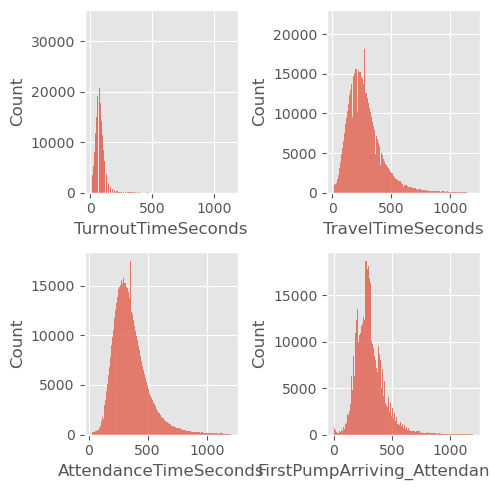

In [71]:
sns.color_palette("crest", as_cmap=True)
fig, axs = plt.subplots(2,2, figsize=(5,5))
sns.histplot(clean_merge.TurnoutTimeSeconds, ax=axs[0,0])
sns.histplot(clean_merge.TravelTimeSeconds, ax=axs[0,1])
sns.histplot(clean_merge.AttendanceTimeSeconds, ax=axs[1,0])
sns.histplot(clean_merge.FirstPumpArriving_AttendanceTime, ax=axs[1,1])
plt.tight_layout()
plt.show()

In [72]:
!pip install pyproj

In [73]:
pip install geopy

Note: you may need to restart the kernel to use updated packages.


In [74]:
from pyproj import Transformer
from geopy.distance import great_circle

# Define transformer for batch conversion
transformer = Transformer.from_crs("epsg:27700", "epsg:4326", always_xy=True)

# Convert all easting/northing in batch using NumPy
lons, lats = transformer.transform(clean_merge["Easting_rounded"].values, clean_merge["Northing_rounded"].values)

# Add new columns to DataFrame
clean_merge["Lat"] = lats
clean_merge["Lon"] = lons

C:\Users\Thesa\AppData\Local\Temp\ipykernel_7796\2807500272.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Thesa\AppData\Local\Temp\ipykernel_7796\2807500272.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [75]:
FRS_coordinates={
    'Acton': (51.507915, -0.276336) , 
    'Addington': (51.351158, -0.023605), 
    'Barking': (51.52982, 0.088809), 
    'Barnet': (51.647239, -0.186118), 
    'Battersea': (51.467306, -0.168992), 
    'Beckenham': (51.407975, -0.03381), 
    'Bethnal Green': (51.52791, -0.052074), 
    'Bexley': (51.461121, 0.153563), 
    'Biggin Hill': (51.314232, 0.034747), 
    'Brixton': (51.463652, -0.109389), 
    'Bromley': (51.406732, 0.016589), 
    'Chelsea': (51.487233, -0.170153), 
    'Chingford': (51.63059, -0.003044), 
    'Chiswick': (51.489993, -0.269113), 
    'City': (51.510003, -0.09206), 
    'Clapham': (51.4654, -0.141051), 
    'Croydon': (51.369071, -0.105199), 
    'Dagenham': (51.559507, 0.15678), 
    'Deptford': (51.485149, -0.034196), 
    'Dockhead': (51.500708, -0.071144), 
    'Ealing': (51.51174, -0.315039), 
    'East Greenwich': (51.487034, 0.022049), 
    'East Ham': (51.523548, 0.056981), 
    'Edmonton': (51.627217, -0.06912),
    'Eltham': (51.45066, 0.0591), 
    'Enfield': (51.660251, -0.05125), 
    'Erith': (51.485616, 0.157079), 
    'Euston': (51.527723, -0.130668), 
    'Feltham': (51.536126, -0.135471), 
    'Finchley': (51.598089, -0.17907), 
    'Forest Hill': (51.44239, -0.043444), 
    'Fulham': (51.477418, -0.20133), 
    'Greenwich': (51.474642, -0.0127), 
    'Hainault': (51.605945, 0.10283), 
    'Hammersmith': (51.49614, -0.22424), 
    'Harold Hill': (51.5946, 0.2329), 
    'Harrow': (51.590833, -0.366337), 
    'Hayes': (51.495068, -0.430967), 
    'Heathrow': (51.480183, -0.45863), 
    'Hendon': (51.588901, -0.228776), 
    'Heston': (51.474977, -0.343292), 
    'Hillingdon': (51.531259, -0.451681), 
    'Holloway': (51.561766, -0.116461), 
    'Homerton': (51.548634, -0.043184), 
    'Hornchurch': (51.564579, 0.220548), 
    'Hornsey': (51.58561, -0.128019), 
    'Ilford': (51.562624, 0.091493), 
    'Islington': (51.539912, -0.102337), 
    'Kensington': (51.502799, -0.190379), 
    'Kentish Town': (51.552957, -0.142053), 
    'Kingston': (51.427797, -0.306333), 
    'Lambeth': (51.490753, -0.122097), 
    'Lambeth River': (51.490753, -0.122097), 
    'Lee Green': (51.45626, 0.013175), 
    'Lewisham': (51.457223, -0.013226), 
    'Leyton': (51.564005, -0.017636), 
    'Leytonstone': (51.561057, 0.008853), 
    'Mill Hill': (51.614985, -0.243591), 
    'Millwall': (51.500806, -0.025725), 
    'Mitcham': (51.397482, -0.172787), 
    'New Cross': (51.473858, -0.047339), 
    'New Malden': (51.399077, -0.245362), 
    'Norbury': (51.407077, -0.121559), 
    'North Kensington': (51.522718, -0.212865), 
    'Northolt': (51.554662, -0.359569), 
    'Old Kent Road': (51.487027, -0.074706), 
    'Orpington': (51.371835, 0.110792), 
    'Paddington': (51.520219, -0.183039), 
    'Park Royal': (51.536515, -0.265157), 
    'Peckham': (51.473869, -0.077979), 
    'Plaistow': (51.520068, 0.031699), 
    'Plumstead': (51.45626, 0.013175), 
    'Poplar': (51.51088, -0.015706), 
    'Purley': (51.332205, -0.124477), 
    'Richmond': (51.467465, -0.284858), 
    'Romford': (51.593238, 0.183295), 
    'Ruislip': (51.588373, -0.436624), 
    'Shadwell': (51.510868, -0.055828), 
    'Shoreditch': (51.526625, -0.084321), 
    'Sidcup': (51.427145, 0.094118), 
    'Soho': (51.512489, -0.130081), 
    'Southall': (51.511223, -0.373985), 
    'Southgate': (51.631257, -0.127342), 
    'Stanmore': (51.603466, -0.297278), 
    'Stoke Newington': (51.562056, -0.07653),
    'Stratford': (51.54321, 0.011631), 
    'Surbiton': (51.392245, -0.297993), 
    'Sutton': (51.369682, -0.210444), 
    'Tooting': (51.437991, -0.162768), 
    'Tottenham': (51.592905, -0.074228), 
    'Twickenham': (51.435297, -0.348598), 
    'Wallington': (51.362348, -0.1482), 
    'Walthamstow': (51.58989, -0.027524), 
    'Wandsworth': (51.456521, -0.201461), 
    'Wembley': (51.551733, -0.304071), 
    'Wennington': (51.506171, 0.220432), 
    'West Hampstead': (51.55194, -0.193074),
    'West Norwood': (51.425983, -0.105596), 
    'Whitechapel': (51.515125, -0.068433), 
    'Willesden': (51.544717, -0.236838), 
    'Wimbledon': (51.415606, -0.196269), 
    'Woodford': (51.60883, 0.026243), 
    'Woodside': (51.386048, -0.06223), 
    'Silvertown': (51.502452, 0.026519), 
    'Kingsland': (51.540099, -0.076285), 
    'Bow': (51.533947, -0.026425), 
    'Downham': (51.433593, 0.011919),
    'Dowgate': (51.510003, -0.09206)
}

clean_merge['FRS_lat'] = clean_merge['IncidentStationGround'].map(lambda IncidentStationGround: FRS_coordinates.get(IncidentStationGround, (None, None))[0])
clean_merge['FRS_lon'] = clean_merge['IncidentStationGround'].map(lambda IncidentStationGround: FRS_coordinates.get(IncidentStationGround, (None, None))[1])

clean_merge.head()


C:\Users\Thesa\AppData\Local\Temp\ipykernel_7796\1703059039.py:112: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Thesa\AppData\Local\Temp\ipykernel_7796\1703059039.py:113: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,index_compat_mobs,IncidentNumber,CalYear_compat_mobs,HourOfCall_compat_mobs,ResourceMobilisationId,PerformanceReporting,DateAndTimeMobilised,DateAndTimeMobile,DateAndTimeArrived,TurnoutTimeSeconds,TravelTimeSeconds,AttendanceTimeSeconds,DateAndTimeLeft,DeployedFromStation_Name,DeployedFromLocation,PumpOrder,DelayCode_Description,Weekday_compat_mobs,Month_compat_mobs,Day_Month_compat_mobs,Incident_Date,index_compat_incidents,DateOfCall,CalYear_compat_incidents,TimeOfCall,HourOfCall_compat_incidents,IncidentGroup,StopCodeDescription,PropertyCategory,AddressQualifier,Postcode_district,ProperCase,Easting_rounded,Northing_rounded,IncidentStationGround,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),Weekday_compat_incidents,Month_compat_incidents,Day_Month_compat_incidents,Day,Lat,Lon,FRS_lat,FRS_lon
1,1,235138081,2009,0,38427,2,2009-01-01 00:02:00,01.01.2009 00:06,01.01.2009 00:08,253.0,89.0,342.0,01.01.2009 00:12,Clapham,Home Station,2,not held up,Thursday,1,1,2009.01.01,0.0,2009-01-01,2009.0,00:00:37,0.0,Special Service,RTC,Road Vehicle,In street close to gazetteer location,SW11,Wandsworth,528650.0,176850.0,Battersea,319.0,Battersea,342.0,Clapham,2.0,2.0,2.0,60.0,255.0,Thursday,1.0,1.0,1,51.475991,-0.148941,51.467306,-0.168992
2,2,2091,2009,0,38429,1,2009-01-01 00:04:00,01.01.2009 00:06,01.01.2009 00:09,151.0,157.0,308.0,01.01.2009 00:16,Edmonton,Home Station,1,not held up,Thursday,1,1,2009.01.01,2.0,2009-01-01,2009.0,00:03:00,0.0,Fire,Secondary Fire,Outdoor,In street outside gazetteer location,N9,Enfield,533750.0,194450.0,Edmonton,308.0,Edmonton,-1.0,-1,1.0,1.0,1.0,60.0,255.0,Thursday,1.0,1.0,1,51.632968,-0.068862,51.627217,-0.069120
3,3,3091,2009,0,38430,1,2009-01-01 00:04:00,01.01.2009 00:06,01.01.2009 00:08,108.0,102.0,210.0,01.01.2009 00:20,Hillingdon,Home Station,1,"Traffic, roadworks, etc",Thursday,1,1,2009.01.01,3.0,2009-01-01,2009.0,00:04:27,0.0,Fire,Secondary Fire,Outdoor,On land associated with building,UB10,Hillingdon,507750.0,182850.0,Hillingdon,210.0,Hillingdon,-1.0,-1,1.0,1.0,1.0,60.0,255.0,Thursday,1.0,1.0,1,51.534283,-0.447922,51.531259,-0.451681
4,4,5091,2009,0,38432,1,2009-01-01 00:06:00,01.01.2009 00:07,01.01.2009 00:09,114.0,119.0,233.0,01.01.2009 00:11,Holloway,Home Station,1,not held up,Thursday,1,1,2009.01.01,4.0,2009-01-01,2009.0,00:05:39,0.0,Fire,Secondary Fire,Outdoor,In street outside gazetteer location,N7,Islington,531050.0,185350.0,Holloway,233.0,Holloway,250.0,Holloway,1.0,2.0,2.0,60.0,255.0,Thursday,1.0,1.0,1,51.551827,-0.111246,51.561766,-0.116461
6,6,6091,2009,0,38434,1,2009-01-01 00:06:00,01.01.2009 00:07,01.01.2009 00:09,83.0,89.0,172.0,01.01.2009 00:15,Kentish Town,Home Station,1,not held up,Thursday,1,1,2009.01.01,5.0,2009-01-01,2009.0,00:06:03,0.0,False Alarm,AFA,Dwelling,Correct incident location,NW5,Camden,529450.0,185250.0,Kentish Town,172.0,Kentish Town,222.0,Kentish Town,1.0,2.0,2.0,60.0,255.0,Thursday,1.0,1.0,1,51.551297,-0.134346,51.552957,-0.142053


In [76]:
clean_merge.isna().sum()

index_compat_mobs                         0
IncidentNumber                            0
CalYear_compat_mobs                       0
HourOfCall_compat_mobs                    0
ResourceMobilisationId                    0
PerformanceReporting                      0
DateAndTimeMobilised                      0
DateAndTimeMobile                         0
DateAndTimeArrived                        0
TurnoutTimeSeconds                        0
TravelTimeSeconds                         0
AttendanceTimeSeconds                     0
DateAndTimeLeft                           0
DeployedFromStation_Name                  0
DeployedFromLocation                      0
PumpOrder                                 0
DelayCode_Description                     0
Weekday_compat_mobs                       0
Month_compat_mobs                         0
Day_Month_compat_mobs                     0
Incident_Date                             0
index_compat_incidents                    0
DateOfCall                      

In [77]:
# Calculate distances using great_circle (Geopy is optimized for geodesic calculations)
clean_merge['distance_km'] = clean_merge.apply(
    lambda row: great_circle((row['Lat'], row['Lon']), (row['FRS_lat'], row['FRS_lon'])).kilometers,
    axis=1
)

# Check the result
clean_merge.head()


C:\Users\Thesa\AppData\Local\Temp\ipykernel_7796\2866105828.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,index_compat_mobs,IncidentNumber,CalYear_compat_mobs,HourOfCall_compat_mobs,ResourceMobilisationId,PerformanceReporting,DateAndTimeMobilised,DateAndTimeMobile,DateAndTimeArrived,TurnoutTimeSeconds,TravelTimeSeconds,AttendanceTimeSeconds,DateAndTimeLeft,DeployedFromStation_Name,DeployedFromLocation,PumpOrder,DelayCode_Description,Weekday_compat_mobs,Month_compat_mobs,Day_Month_compat_mobs,Incident_Date,index_compat_incidents,DateOfCall,CalYear_compat_incidents,TimeOfCall,HourOfCall_compat_incidents,IncidentGroup,StopCodeDescription,PropertyCategory,AddressQualifier,Postcode_district,ProperCase,Easting_rounded,Northing_rounded,IncidentStationGround,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),Weekday_compat_incidents,Month_compat_incidents,Day_Month_compat_incidents,Day,Lat,Lon,FRS_lat,FRS_lon,distance_km
1,1,235138081,2009,0,38427,2,2009-01-01 00:02:00,01.01.2009 00:06,01.01.2009 00:08,253.0,89.0,342.0,01.01.2009 00:12,Clapham,Home Station,2,not held up,Thursday,1,1,2009.01.01,0.0,2009-01-01,2009.0,00:00:37,0.0,Special Service,RTC,Road Vehicle,In street close to gazetteer location,SW11,Wandsworth,528650.0,176850.0,Battersea,319.0,Battersea,342.0,Clapham,2.0,2.0,2.0,60.0,255.0,Thursday,1.0,1.0,1,51.475991,-0.148941,51.467306,-0.168992,1.691595
2,2,2091,2009,0,38429,1,2009-01-01 00:04:00,01.01.2009 00:06,01.01.2009 00:09,151.0,157.0,308.0,01.01.2009 00:16,Edmonton,Home Station,1,not held up,Thursday,1,1,2009.01.01,2.0,2009-01-01,2009.0,00:03:00,0.0,Fire,Secondary Fire,Outdoor,In street outside gazetteer location,N9,Enfield,533750.0,194450.0,Edmonton,308.0,Edmonton,-1.0,-1,1.0,1.0,1.0,60.0,255.0,Thursday,1.0,1.0,1,51.632968,-0.068862,51.627217,-0.069120,0.639746
3,3,3091,2009,0,38430,1,2009-01-01 00:04:00,01.01.2009 00:06,01.01.2009 00:08,108.0,102.0,210.0,01.01.2009 00:20,Hillingdon,Home Station,1,"Traffic, roadworks, etc",Thursday,1,1,2009.01.01,3.0,2009-01-01,2009.0,00:04:27,0.0,Fire,Secondary Fire,Outdoor,On land associated with building,UB10,Hillingdon,507750.0,182850.0,Hillingdon,210.0,Hillingdon,-1.0,-1,1.0,1.0,1.0,60.0,255.0,Thursday,1.0,1.0,1,51.534283,-0.447922,51.531259,-0.451681,0.425043
4,4,5091,2009,0,38432,1,2009-01-01 00:06:00,01.01.2009 00:07,01.01.2009 00:09,114.0,119.0,233.0,01.01.2009 00:11,Holloway,Home Station,1,not held up,Thursday,1,1,2009.01.01,4.0,2009-01-01,2009.0,00:05:39,0.0,Fire,Secondary Fire,Outdoor,In street outside gazetteer location,N7,Islington,531050.0,185350.0,Holloway,233.0,Holloway,250.0,Holloway,1.0,2.0,2.0,60.0,255.0,Thursday,1.0,1.0,1,51.551827,-0.111246,51.561766,-0.116461,1.162546
6,6,6091,2009,0,38434,1,2009-01-01 00:06:00,01.01.2009 00:07,01.01.2009 00:09,83.0,89.0,172.0,01.01.2009 00:15,Kentish Town,Home Station,1,not held up,Thursday,1,1,2009.01.01,5.0,2009-01-01,2009.0,00:06:03,0.0,False Alarm,AFA,Dwelling,Correct incident location,NW5,Camden,529450.0,185250.0,Kentish Town,172.0,Kentish Town,222.0,Kentish Town,1.0,2.0,2.0,60.0,255.0,Thursday,1.0,1.0,1,51.551297,-0.134346,51.552957,-0.142053,0.563928


In [78]:
clean_merge=clean_merge.drop(['Lat', 'Lon', 'FRS_lat', 'FRS_lon', 'ResourceMobilisationId', 'DateAndTimeLeft', 'index_compat_mobs', 'index_compat_incidents', 'CalYear_compat_incidents', 'TimeOfCall', 'Day_Month_compat_mobs', 'Weekday_compat_incidents', 'Month_compat_incidents', 'Day_Month_compat_incidents', 'Day', 'Easting_rounded', 'Northing_rounded', 'HourOfCall_compat_incidents'], axis=1)

In [79]:
clean_merge['DateAndTimeMobile']=pd.to_datetime(clean_merge['DateAndTimeMobile'], format='mixed')
clean_merge['DateAndTimeArrived']=pd.to_datetime(clean_merge['DateAndTimeArrived'], format='mixed')
clean_merge['Incident_Date']=pd.to_datetime(clean_merge['Incident_Date'], format='mixed')

In [80]:
dupe_clean_merge=clean_merge.copy()

In [81]:
clean_merge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1514797 entries, 1 to 2489018
Data columns (total 35 columns):
 #   Column                                  Non-Null Count    Dtype         
---  ------                                  --------------    -----         
 0   IncidentNumber                          1514797 non-null  int64         
 1   CalYear_compat_mobs                     1514797 non-null  int64         
 2   HourOfCall_compat_mobs                  1514797 non-null  int64         
 3   PerformanceReporting                    1514797 non-null  object        
 4   DateAndTimeMobilised                    1514797 non-null  datetime64[ns]
 5   DateAndTimeMobile                       1514797 non-null  datetime64[ns]
 6   DateAndTimeArrived                      1514797 non-null  datetime64[ns]
 7   TurnoutTimeSeconds                      1514797 non-null  float64       
 8   TravelTimeSeconds                       1514797 non-null  float64       
 9   AttendanceTimeSeconds        

In [82]:
clean_merge.isna().sum()

IncidentNumber                            0
CalYear_compat_mobs                       0
HourOfCall_compat_mobs                    0
PerformanceReporting                      0
DateAndTimeMobilised                      0
DateAndTimeMobile                         0
DateAndTimeArrived                        0
TurnoutTimeSeconds                        0
TravelTimeSeconds                         0
AttendanceTimeSeconds                     0
DeployedFromStation_Name                  0
DeployedFromLocation                      0
PumpOrder                                 0
DelayCode_Description                     0
Weekday_compat_mobs                       0
Month_compat_mobs                         0
Incident_Date                             0
DateOfCall                                0
IncidentGroup                             0
StopCodeDescription                       0
PropertyCategory                          0
AddressQualifier                          0
Postcode_district               

In [83]:
clean_merge['DeployedFromLocation'].astype('object')
clean_merge['DelayCode_Description'].astype('object')
clean_merge['PropertyCategory'].astype('object')
clean_merge['IncidentGroup'].astype('object')
clean_merge['Weekday_compat_mobs'].astype('object')
clean_merge['PerformanceReporting'].astype('object')
clean_merge['AddressQualifier'].astype('object')
clean_merge['IncidentStationGround'].astype('object')
clean_merge['FirstPumpArriving_DeployedFromStation'].astype('object')
clean_merge['SecondPumpArriving_DeployedFromStation'].astype('object')
clean_merge['StopCodeDescription'].astype('object')
clean_merge['ProperCase'].astype('object')
clean_merge['DeployedFromStation_Name'].astype('object')
clean_merge['Postcode_district'].astype('object')

1          SW11
2            N9
3          UB10
4            N7
6           NW5
           ... 
2489014      W7
2489015    SE27
2489016    SE17
2489017    SE17
2489018    IG11
Name: Postcode_district, Length: 1514797, dtype: object

In [84]:
clean_merge.info()
clean_merge.shape

<class 'pandas.core.frame.DataFrame'>
Index: 1514797 entries, 1 to 2489018
Data columns (total 35 columns):
 #   Column                                  Non-Null Count    Dtype         
---  ------                                  --------------    -----         
 0   IncidentNumber                          1514797 non-null  int64         
 1   CalYear_compat_mobs                     1514797 non-null  int64         
 2   HourOfCall_compat_mobs                  1514797 non-null  int64         
 3   PerformanceReporting                    1514797 non-null  object        
 4   DateAndTimeMobilised                    1514797 non-null  datetime64[ns]
 5   DateAndTimeMobile                       1514797 non-null  datetime64[ns]
 6   DateAndTimeArrived                      1514797 non-null  datetime64[ns]
 7   TurnoutTimeSeconds                      1514797 non-null  float64       
 8   TravelTimeSeconds                       1514797 non-null  float64       
 9   AttendanceTimeSeconds        

(1514797, 35)

In [85]:
clean_merge = clean_merge.reset_index(drop=True)
clean_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1514797 entries, 0 to 1514796
Data columns (total 35 columns):
 #   Column                                  Non-Null Count    Dtype         
---  ------                                  --------------    -----         
 0   IncidentNumber                          1514797 non-null  int64         
 1   CalYear_compat_mobs                     1514797 non-null  int64         
 2   HourOfCall_compat_mobs                  1514797 non-null  int64         
 3   PerformanceReporting                    1514797 non-null  object        
 4   DateAndTimeMobilised                    1514797 non-null  datetime64[ns]
 5   DateAndTimeMobile                       1514797 non-null  datetime64[ns]
 6   DateAndTimeArrived                      1514797 non-null  datetime64[ns]
 7   TurnoutTimeSeconds                      1514797 non-null  float64       
 8   TravelTimeSeconds                       1514797 non-null  float64       
 9   AttendanceTimeSeconds   

In [86]:
dd_clean_merge=clean_merge.copy()

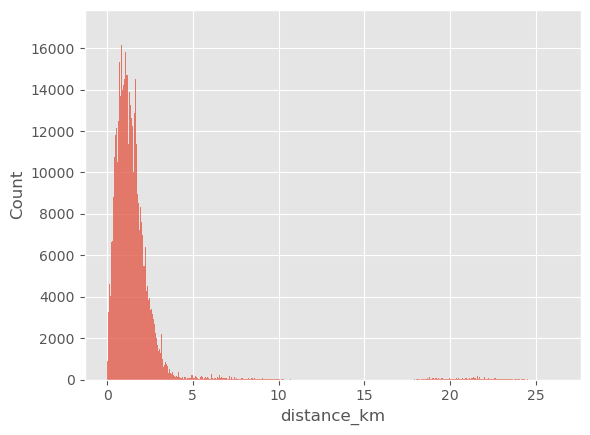

In [87]:
sns.histplot(clean_merge.distance_km)
plt.show(sns)

In [88]:
clean_merge.to_csv('clean_merge_v2.csv', sep=';', index=False)

In [89]:
!pip install category_encoders

In [90]:
import sklearn

In [91]:
print(sklearn.__version__)

1.6.1


In [92]:
pip install --upgrade scikit-learn

In [93]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
import category_encoders as ce
from collections import Counter

In [94]:
clean_merge=clean_merge.drop(['DateAndTimeMobilised', 'DateAndTimeMobile', 'DateAndTimeArrived', 'Incident_Date'], axis=1)

In [95]:
num_vars2=clean_merge[['AttendanceTimeSeconds', 'FirstPumpArriving_AttendanceTime', 'SecondPumpArriving_AttendanceTime', 'NumPumpsAttending', 'PumpCount', 'PumpMinutesRounded', 'Notional Cost (£)', 'distance_km', 'PumpOrder', 'Month_compat_mobs', 'CalYear_compat_mobs', 'HourOfCall_compat_mobs']]

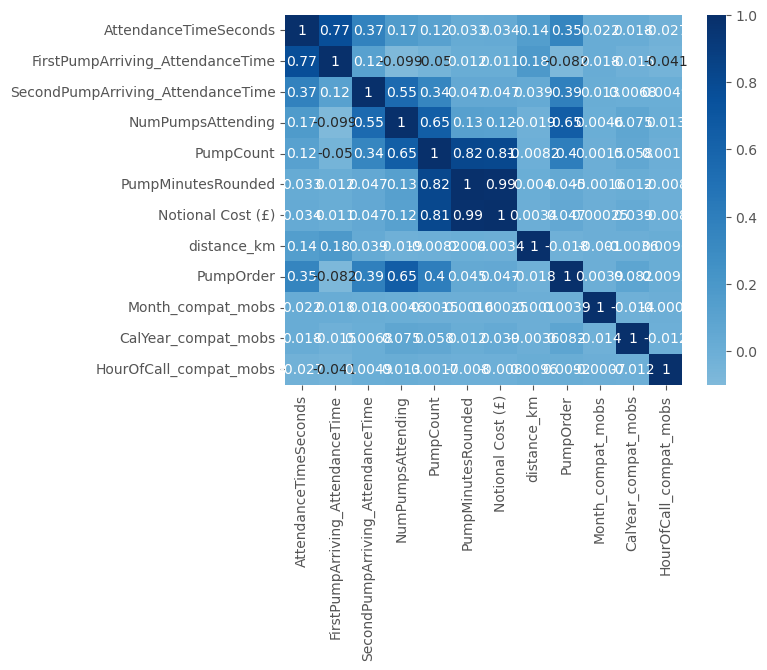

In [96]:
sns.heatmap(num_vars2.corr(), annot=True, cmap='Blues', center=0)
plt.show(sns)

In [97]:
clean_merge=clean_merge.drop(['DateOfCall', 'IncidentNumber'], axis=1)

In [98]:
clean_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1514797 entries, 0 to 1514796
Data columns (total 29 columns):
 #   Column                                  Non-Null Count    Dtype  
---  ------                                  --------------    -----  
 0   CalYear_compat_mobs                     1514797 non-null  int64  
 1   HourOfCall_compat_mobs                  1514797 non-null  int64  
 2   PerformanceReporting                    1514797 non-null  object 
 3   TurnoutTimeSeconds                      1514797 non-null  float64
 4   TravelTimeSeconds                       1514797 non-null  float64
 5   AttendanceTimeSeconds                   1514797 non-null  float64
 6   DeployedFromStation_Name                1514797 non-null  object 
 7   DeployedFromLocation                    1514797 non-null  object 
 8   PumpOrder                               1514797 non-null  int64  
 9   DelayCode_Description                   1514797 non-null  object 
 10  Weekday_compat_mobs           

In [99]:
clean_merge.nunique()

CalYear_compat_mobs                           16
HourOfCall_compat_mobs                        24
PerformanceReporting                           3
TurnoutTimeSeconds                           805
TravelTimeSeconds                           1187
AttendanceTimeSeconds                       1200
DeployedFromStation_Name                     116
DeployedFromLocation                           2
PumpOrder                                     11
DelayCode_Description                         12
Weekday_compat_mobs                            7
Month_compat_mobs                             12
IncidentGroup                                  3
StopCodeDescription                           28
PropertyCategory                               9
AddressQualifier                              11
Postcode_district                            317
ProperCase                                    33
IncidentStationGround                        102
FirstPumpArriving_AttendanceTime            1200
FirstPumpArriving_De

In [100]:
cat_cols=clean_merge.select_dtypes(include=['object'])

In [101]:
num_cols=clean_merge[['HourOfCall_compat_mobs', 'Month_compat_mobs', 'CalYear_compat_mobs', 'TurnoutTimeSeconds', 'TravelTimeSeconds', 'AttendanceTimeSeconds', 'Notional Cost (£)', 'distance_km', 'PumpMinutesRounded', 'PumpCount', 'NumPumpsAttending', 'FirstPumpArriving_AttendanceTime', 'SecondPumpArriving_AttendanceTime', 'NumStationsWithPumpsAttending', 'NumStationsWithPumpsAttending', 'PumpOrder']]
num_cols.head()

,HourOfCall_compat_mobs,Month_compat_mobs,CalYear_compat_mobs,TurnoutTimeSeconds,TravelTimeSeconds,AttendanceTimeSeconds,Notional Cost (£),distance_km,PumpMinutesRounded,PumpCount,NumPumpsAttending,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumStationsWithPumpsAttending,PumpOrder
0,0,1,2009,253.0,89.0,342.0,255.0,1.691595,60.0,2.0,2.0,319.0,342.0,2.0,2.0,2
1,0,1,2009,151.0,157.0,308.0,255.0,0.639746,60.0,1.0,1.0,308.0,-1.0,1.0,1.0,1
2,0,1,2009,108.0,102.0,210.0,255.0,0.425043,60.0,1.0,1.0,210.0,-1.0,1.0,1.0,1
3,0,1,2009,114.0,119.0,233.0,255.0,1.162546,60.0,2.0,2.0,233.0,250.0,1.0,1.0,1
4,0,1,2009,83.0,89.0,172.0,255.0,0.563928,60.0,2.0,2.0,172.0,222.0,1.0,1.0,1


In [102]:
low_cardinality = []
high_cardinality = []
for col in cat_cols:
    if clean_merge[col].nunique() <=10:
        low_cardinality.append(col)
    else:
        high_cardinality.append(col)

print(low_cardinality)
print(high_cardinality)

['PerformanceReporting', 'DeployedFromLocation', 'Weekday_compat_mobs', 'IncidentGroup', 'PropertyCategory']
['DeployedFromStation_Name', 'DelayCode_Description', 'StopCodeDescription', 'AddressQualifier', 'Postcode_district', 'ProperCase', 'IncidentStationGround', 'FirstPumpArriving_DeployedFromStation', 'SecondPumpArriving_DeployedFromStation']


In [103]:
def frequency_encode(clean_merge, columns):
    for col in columns:
        freq_map = clean_merge[col].value_counts() / len(clean_merge)
        clean_merge[col] = clean_merge[col].map(freq_map)
    return clean_merge

clean_merge_encoded = frequency_encode(clean_merge.copy(), high_cardinality)

In [104]:
clean_merge_encoded.head()

,CalYear_compat_mobs,HourOfCall_compat_mobs,PerformanceReporting,TurnoutTimeSeconds,TravelTimeSeconds,AttendanceTimeSeconds,DeployedFromStation_Name,DeployedFromLocation,PumpOrder,DelayCode_Description,Weekday_compat_mobs,Month_compat_mobs,IncidentGroup,StopCodeDescription,PropertyCategory,AddressQualifier,Postcode_district,ProperCase,IncidentStationGround,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),distance_km
0,2009,0,2,253.0,89.0,342.0,0.010037,Home Station,2,0.469477,Thursday,1,Special Service,0.036991,Road Vehicle,0.035991,0.009080,0.033752,0.008562,319.0,0.007963,342.0,0.006378,2.0,2.0,2.0,60.0,255.0,1.691595
1,2009,0,1,151.0,157.0,308.0,0.011193,Home Station,1,0.469477,Thursday,1,Fire,0.070277,Outdoor,0.056977,0.005213,0.028938,0.011889,308.0,0.010859,-1.0,0.400062,1.0,1.0,1.0,60.0,255.0,0.639746
2,2009,0,1,108.0,102.0,210.0,0.009930,Home Station,1,0.205457,Thursday,1,Fire,0.070277,Outdoor,0.054395,0.002425,0.032239,0.009477,210.0,0.010137,-1.0,0.400062,1.0,1.0,1.0,60.0,255.0,0.425043
3,2009,0,1,114.0,119.0,233.0,0.011176,Home Station,1,0.469477,Thursday,1,Fire,0.070277,Outdoor,0.056977,0.007462,0.031730,0.012184,233.0,0.011459,250.0,0.005921,1.0,2.0,2.0,60.0,255.0,1.162546
4,2009,0,1,83.0,89.0,172.0,0.017569,Home Station,1,0.469477,Thursday,1,False Alarm,0.446464,Dwelling,0.596625,0.003932,0.050151,0.016787,172.0,0.017036,222.0,0.013082,1.0,2.0,2.0,60.0,255.0,0.563928


In [105]:
clean_merge_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1514797 entries, 0 to 1514796
Data columns (total 29 columns):
 #   Column                                  Non-Null Count    Dtype  
---  ------                                  --------------    -----  
 0   CalYear_compat_mobs                     1514797 non-null  int64  
 1   HourOfCall_compat_mobs                  1514797 non-null  int64  
 2   PerformanceReporting                    1514797 non-null  object 
 3   TurnoutTimeSeconds                      1514797 non-null  float64
 4   TravelTimeSeconds                       1514797 non-null  float64
 5   AttendanceTimeSeconds                   1514797 non-null  float64
 6   DeployedFromStation_Name                1514797 non-null  float64
 7   DeployedFromLocation                    1514797 non-null  object 
 8   PumpOrder                               1514797 non-null  int64  
 9   DelayCode_Description                   1514797 non-null  float64
 10  Weekday_compat_mobs           

In [106]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
X= clean_merge_encoded.drop(columns = ['AttendanceTimeSeconds'])
y= clean_merge_encoded['AttendanceTimeSeconds']

low_cardinality = [col for col in X.select_dtypes(include=['object']).columns if col not in high_cardinality]

onehot_encoder = OneHotEncoder(sparse_output=False, drop = 'first')

X_onehot_encoded = onehot_encoder.fit_transform(X[low_cardinality])
onehot_columns = onehot_encoder.get_feature_names_out(low_cardinality)
X_onehot_encoded_df = pd.DataFrame(X_onehot_encoded, columns = onehot_columns)
X_onehot_encoded_num_df = pd.concat([X_onehot_encoded_df, num_cols], axis=1)

X_high_cardinality = X[high_cardinality]
X_combined=pd.concat([X_onehot_encoded_num_df, X_high_cardinality], axis =1)

X_combined=X_combined.drop(columns=['AttendanceTimeSeconds'])

X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.3, random_state=42)


In [107]:
X_train.head()

,PerformanceReporting_2,PerformanceReporting_Not Used,DeployedFromLocation_Other Station,Weekday_compat_mobs_Monday,Weekday_compat_mobs_Saturday,Weekday_compat_mobs_Sunday,Weekday_compat_mobs_Thursday,Weekday_compat_mobs_Tuesday,Weekday_compat_mobs_Wednesday,IncidentGroup_Fire,IncidentGroup_Special Service,PropertyCategory_Boat,PropertyCategory_Dwelling,PropertyCategory_Non Residential,PropertyCategory_Other Residential,PropertyCategory_Outdoor,PropertyCategory_Outdoor Structure,PropertyCategory_Rail Vehicle,PropertyCategory_Road Vehicle,HourOfCall_compat_mobs,Month_compat_mobs,CalYear_compat_mobs,TurnoutTimeSeconds,TravelTimeSeconds,Notional Cost (£),distance_km,PumpMinutesRounded,PumpCount,NumPumpsAttending,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumStationsWithPumpsAttending,PumpOrder,DeployedFromStation_Name,DelayCode_Description,StopCodeDescription,AddressQualifier,Postcode_district,ProperCase,IncidentStationGround,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_DeployedFromStation
1217440,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,13,6,2022,23.0,441.0,364.0,0.629166,60.0,2.0,2.0,359.0,464.0,2.0,2.0,2,0.008850,0.469477,0.446464,0.596625,0.005498,0.036353,0.007806,0.006483,0.004922
1101752,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,21,4,2021,75.0,181.0,352.0,1.575489,60.0,2.0,2.0,256.0,537.0,2.0,2.0,1,0.005018,0.469477,0.446464,0.596625,0.020174,0.038847,0.005050,0.005204,0.000354
200757,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,11,3,2011,87.0,354.0,260.0,1.233103,60.0,3.0,3.0,292.0,370.0,2.0,2.0,3,0.007053,0.469477,0.446464,0.215888,0.002934,0.032239,0.011167,0.011124,0.007266
1409175,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20,1,2024,47.0,194.0,724.0,0.146880,112.0,6.0,5.0,163.0,241.0,5.0,5.0,2,0.012220,0.205457,0.446464,0.596625,0.015615,0.045372,0.005945,0.005492,0.009166
1488445,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,12,9,2024,69.0,214.0,430.0,1.810568,60.0,2.0,2.0,245.0,283.0,1.0,1.0,2,0.016094,0.205457,0.446464,0.215888,0.004583,0.028316,0.016247,0.015956,0.010162


In [108]:
X_combined.to_csv('X_combined.csv', sep=';', index=False)

In [109]:
y_test.to_csv('y_test.csv', sep=';', index=False)

In [110]:
y_test.head()

75412      519.0
1293925    314.0
321430     332.0
193403     208.0
791040     533.0
Name: AttendanceTimeSeconds, dtype: float64

In [111]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1060357 entries, 1217440 to 121958
Data columns (total 43 columns):
 #   Column                                  Non-Null Count    Dtype  
---  ------                                  --------------    -----  
 0   PerformanceReporting_2                  1060357 non-null  float64
 1   PerformanceReporting_Not Used           1060357 non-null  float64
 2   DeployedFromLocation_Other Station      1060357 non-null  float64
 3   Weekday_compat_mobs_Monday              1060357 non-null  float64
 4   Weekday_compat_mobs_Saturday            1060357 non-null  float64
 5   Weekday_compat_mobs_Sunday              1060357 non-null  float64
 6   Weekday_compat_mobs_Thursday            1060357 non-null  float64
 7   Weekday_compat_mobs_Tuesday             1060357 non-null  float64
 8   Weekday_compat_mobs_Wednesday           1060357 non-null  float64
 9   IncidentGroup_Fire                      1060357 non-null  float64
 10  IncidentGroup_Special Service 

In [112]:
from sklearn.preprocessing import MinMaxScaler
scaler1 = MinMaxScaler()
X_train[['TurnoutTimeSeconds', 'TravelTimeSeconds', 'FirstPumpArriving_AttendanceTime', 'SecondPumpArriving_AttendanceTime', 'distance_km', 'Notional Cost (£)']]=scaler1.fit_transform(X_train[['TurnoutTimeSeconds', 'TravelTimeSeconds', 'FirstPumpArriving_AttendanceTime', 'SecondPumpArriving_AttendanceTime', 'distance_km', 'Notional Cost (£)']])
X_train.head()

,PerformanceReporting_2,PerformanceReporting_Not Used,DeployedFromLocation_Other Station,Weekday_compat_mobs_Monday,Weekday_compat_mobs_Saturday,Weekday_compat_mobs_Sunday,Weekday_compat_mobs_Thursday,Weekday_compat_mobs_Tuesday,Weekday_compat_mobs_Wednesday,IncidentGroup_Fire,IncidentGroup_Special Service,PropertyCategory_Boat,PropertyCategory_Dwelling,PropertyCategory_Non Residential,PropertyCategory_Other Residential,PropertyCategory_Outdoor,PropertyCategory_Outdoor Structure,PropertyCategory_Rail Vehicle,PropertyCategory_Road Vehicle,HourOfCall_compat_mobs,Month_compat_mobs,CalYear_compat_mobs,TurnoutTimeSeconds,TravelTimeSeconds,Notional Cost (£),distance_km,PumpMinutesRounded,PumpCount,NumPumpsAttending,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumStationsWithPumpsAttending,PumpOrder,DeployedFromStation_Name,DelayCode_Description,StopCodeDescription,AddressQualifier,Postcode_district,ProperCase,IncidentStationGround,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_DeployedFromStation
1217440,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,13,6,2022,0.010772,0.360475,0.000252,0.023666,60.0,2.0,2.0,0.298582,0.387177,2.0,2.0,2,0.008850,0.469477,0.446464,0.596625,0.005498,0.036353,0.007806,0.006483,0.004922
1101752,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,21,4,2021,0.057451,0.139949,0.000224,0.059665,60.0,2.0,2.0,0.212677,0.447960,2.0,2.0,1,0.005018,0.469477,0.446464,0.596625,0.020174,0.038847,0.005050,0.005204,0.000354
200757,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,11,3,2011,0.068223,0.286684,0.000012,0.046640,60.0,3.0,3.0,0.242702,0.308909,2.0,2.0,3,0.007053,0.469477,0.446464,0.215888,0.002934,0.032239,0.011167,0.011124,0.007266
1409175,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20,1,2024,0.032316,0.150975,0.001082,0.005319,112.0,6.0,5.0,0.135113,0.201499,5.0,5.0,2,0.012220,0.205457,0.446464,0.596625,0.015615,0.045372,0.005945,0.005492,0.009166
1488445,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,12,9,2024,0.052065,0.167939,0.000404,0.068608,60.0,2.0,2.0,0.203503,0.236470,1.0,1.0,2,0.016094,0.205457,0.446464,0.215888,0.004583,0.028316,0.016247,0.015956,0.010162


In [113]:
X_test[['TurnoutTimeSeconds', 'TravelTimeSeconds', 'FirstPumpArriving_AttendanceTime', 'SecondPumpArriving_AttendanceTime', 'distance_km', 'Notional Cost (£)']]=scaler1.transform(X_test[['TurnoutTimeSeconds', 'TravelTimeSeconds', 'FirstPumpArriving_AttendanceTime', 'SecondPumpArriving_AttendanceTime', 'distance_km', 'Notional Cost (£)']])
X_test.head()

,PerformanceReporting_2,PerformanceReporting_Not Used,DeployedFromLocation_Other Station,Weekday_compat_mobs_Monday,Weekday_compat_mobs_Saturday,Weekday_compat_mobs_Sunday,Weekday_compat_mobs_Thursday,Weekday_compat_mobs_Tuesday,Weekday_compat_mobs_Wednesday,IncidentGroup_Fire,IncidentGroup_Special Service,PropertyCategory_Boat,PropertyCategory_Dwelling,PropertyCategory_Non Residential,PropertyCategory_Other Residential,PropertyCategory_Outdoor,PropertyCategory_Outdoor Structure,PropertyCategory_Rail Vehicle,PropertyCategory_Road Vehicle,HourOfCall_compat_mobs,Month_compat_mobs,CalYear_compat_mobs,TurnoutTimeSeconds,TravelTimeSeconds,Notional Cost (£),distance_km,PumpMinutesRounded,PumpCount,NumPumpsAttending,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumStationsWithPumpsAttending,PumpOrder,DeployedFromStation_Name,DelayCode_Description,StopCodeDescription,AddressQualifier,Postcode_district,ProperCase,IncidentStationGround,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_DeployedFromStation
75412,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,15,11,2009,0.072711,0.348601,0.000672,0.052484,126.0,3.0,3.0,0.331943,0.427977,2.0,2.0,3,0.012495,0.469477,0.124588,0.596625,0.002917,0.043056,0.011998,0.011941,0.007763
1293925,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,16,1,2023,0.078097,0.169635,0.000335,0.035025,66.0,2.0,1.0,0.261051,0.000000,1.0,1.0,1,0.014593,0.205457,0.013480,0.596625,0.003034,0.033084,0.017900,0.014972,0.400062
321430,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,18,7,2012,0.118492,0.146735,0.000272,0.004884,86.0,3.0,3.0,0.102585,0.277269,2.0,2.0,2,0.002809,0.205457,0.124588,0.596625,0.016483,0.043056,0.021189,0.019520,0.000910
193403,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,23,2,2011,0.061939,0.094996,0.000012,0.013803,60.0,4.0,4.0,0.172644,0.179850,2.0,2.0,1,0.013075,0.469477,0.006629,0.596625,0.006405,0.039432,0.013731,0.013129,0.009319
791040,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,1,2018,0.070916,0.362171,0.000168,0.101415,60.0,1.0,1.0,0.443703,0.000000,1.0,1.0,1,0.005804,0.065559,0.047718,0.596625,0.011125,0.030405,0.010013,0.005375,0.400062


In [114]:
from sklearn.preprocessing import RobustScaler
scalerR = RobustScaler()
X_train[['NumPumpsAttending', 'PumpCount', 'PumpMinutesRounded', 'PumpOrder', 'NumStationsWithPumpsAttending']]=scalerR.fit_transform(X_train[['NumPumpsAttending', 'PumpCount', 'PumpMinutesRounded', 'PumpOrder', 'NumStationsWithPumpsAttending']])
X_train.head()

,PerformanceReporting_2,PerformanceReporting_Not Used,DeployedFromLocation_Other Station,Weekday_compat_mobs_Monday,Weekday_compat_mobs_Saturday,Weekday_compat_mobs_Sunday,Weekday_compat_mobs_Thursday,Weekday_compat_mobs_Tuesday,Weekday_compat_mobs_Wednesday,IncidentGroup_Fire,IncidentGroup_Special Service,PropertyCategory_Boat,PropertyCategory_Dwelling,PropertyCategory_Non Residential,PropertyCategory_Other Residential,PropertyCategory_Outdoor,PropertyCategory_Outdoor Structure,PropertyCategory_Rail Vehicle,PropertyCategory_Road Vehicle,HourOfCall_compat_mobs,Month_compat_mobs,CalYear_compat_mobs,TurnoutTimeSeconds,TravelTimeSeconds,Notional Cost (£),distance_km,PumpMinutesRounded,PumpCount,NumPumpsAttending,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumStationsWithPumpsAttending,PumpOrder,DeployedFromStation_Name,DelayCode_Description,StopCodeDescription,AddressQualifier,Postcode_district,ProperCase,IncidentStationGround,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_DeployedFromStation
1217440,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,13,6,2022,0.010772,0.360475,0.000252,0.023666,0.0,0.0,0.0,0.298582,0.387177,1.0,1.0,1.0,0.008850,0.469477,0.446464,0.596625,0.005498,0.036353,0.007806,0.006483,0.004922
1101752,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,21,4,2021,0.057451,0.139949,0.000224,0.059665,0.0,0.0,0.0,0.212677,0.447960,1.0,1.0,0.0,0.005018,0.469477,0.446464,0.596625,0.020174,0.038847,0.005050,0.005204,0.000354
200757,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,11,3,2011,0.068223,0.286684,0.000012,0.046640,0.0,1.0,1.0,0.242702,0.308909,1.0,1.0,2.0,0.007053,0.469477,0.446464,0.215888,0.002934,0.032239,0.011167,0.011124,0.007266
1409175,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20,1,2024,0.032316,0.150975,0.001082,0.005319,52.0,4.0,3.0,0.135113,0.201499,4.0,4.0,1.0,0.012220,0.205457,0.446464,0.596625,0.015615,0.045372,0.005945,0.005492,0.009166
1488445,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,12,9,2024,0.052065,0.167939,0.000404,0.068608,0.0,0.0,0.0,0.203503,0.236470,0.0,0.0,1.0,0.016094,0.205457,0.446464,0.215888,0.004583,0.028316,0.016247,0.015956,0.010162


In [115]:
X_test[['NumPumpsAttending', 'PumpCount', 'PumpMinutesRounded', 'PumpOrder', 'NumStationsWithPumpsAttending']]=scalerR.transform(X_test[['NumPumpsAttending', 'PumpCount', 'PumpMinutesRounded', 'PumpOrder', 'NumStationsWithPumpsAttending']])
X_test.head()

,PerformanceReporting_2,PerformanceReporting_Not Used,DeployedFromLocation_Other Station,Weekday_compat_mobs_Monday,Weekday_compat_mobs_Saturday,Weekday_compat_mobs_Sunday,Weekday_compat_mobs_Thursday,Weekday_compat_mobs_Tuesday,Weekday_compat_mobs_Wednesday,IncidentGroup_Fire,IncidentGroup_Special Service,PropertyCategory_Boat,PropertyCategory_Dwelling,PropertyCategory_Non Residential,PropertyCategory_Other Residential,PropertyCategory_Outdoor,PropertyCategory_Outdoor Structure,PropertyCategory_Rail Vehicle,PropertyCategory_Road Vehicle,HourOfCall_compat_mobs,Month_compat_mobs,CalYear_compat_mobs,TurnoutTimeSeconds,TravelTimeSeconds,Notional Cost (£),distance_km,PumpMinutesRounded,PumpCount,NumPumpsAttending,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumStationsWithPumpsAttending,PumpOrder,DeployedFromStation_Name,DelayCode_Description,StopCodeDescription,AddressQualifier,Postcode_district,ProperCase,IncidentStationGround,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_DeployedFromStation
75412,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,15,11,2009,0.072711,0.348601,0.000672,0.052484,66.0,1.0,1.0,0.331943,0.427977,1.0,1.0,2.0,0.012495,0.469477,0.124588,0.596625,0.002917,0.043056,0.011998,0.011941,0.007763
1293925,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,16,1,2023,0.078097,0.169635,0.000335,0.035025,6.0,0.0,-1.0,0.261051,0.000000,0.0,0.0,0.0,0.014593,0.205457,0.013480,0.596625,0.003034,0.033084,0.017900,0.014972,0.400062
321430,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,18,7,2012,0.118492,0.146735,0.000272,0.004884,26.0,1.0,1.0,0.102585,0.277269,1.0,1.0,1.0,0.002809,0.205457,0.124588,0.596625,0.016483,0.043056,0.021189,0.019520,0.000910
193403,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,23,2,2011,0.061939,0.094996,0.000012,0.013803,0.0,2.0,2.0,0.172644,0.179850,1.0,1.0,0.0,0.013075,0.469477,0.006629,0.596625,0.006405,0.039432,0.013731,0.013129,0.009319
791040,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,1,2018,0.070916,0.362171,0.000168,0.101415,0.0,-1.0,-1.0,0.443703,0.000000,0.0,0.0,0.0,0.005804,0.065559,0.047718,0.596625,0.011125,0.030405,0.010013,0.005375,0.400062


In [116]:
from sklearn.preprocessing import StandardScaler
scalerS=StandardScaler()
X_train[['DeployedFromStation_Name', 'ProperCase', 'StopCodeDescription', 'Postcode_district', 'IncidentStationGround', 'FirstPumpArriving_DeployedFromStation', 'SecondPumpArriving_DeployedFromStation']] = scalerS.fit_transform(X_train[['DeployedFromStation_Name', 'ProperCase', 'StopCodeDescription', 'Postcode_district', 'IncidentStationGround', 'FirstPumpArriving_DeployedFromStation', 'SecondPumpArriving_DeployedFromStation']])
X_train.head()

,PerformanceReporting_2,PerformanceReporting_Not Used,DeployedFromLocation_Other Station,Weekday_compat_mobs_Monday,Weekday_compat_mobs_Saturday,Weekday_compat_mobs_Sunday,Weekday_compat_mobs_Thursday,Weekday_compat_mobs_Tuesday,Weekday_compat_mobs_Wednesday,IncidentGroup_Fire,IncidentGroup_Special Service,PropertyCategory_Boat,PropertyCategory_Dwelling,PropertyCategory_Non Residential,PropertyCategory_Other Residential,PropertyCategory_Outdoor,PropertyCategory_Outdoor Structure,PropertyCategory_Rail Vehicle,PropertyCategory_Road Vehicle,HourOfCall_compat_mobs,Month_compat_mobs,CalYear_compat_mobs,TurnoutTimeSeconds,TravelTimeSeconds,Notional Cost (£),distance_km,PumpMinutesRounded,PumpCount,NumPumpsAttending,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumStationsWithPumpsAttending,PumpOrder,DeployedFromStation_Name,DelayCode_Description,StopCodeDescription,AddressQualifier,Postcode_district,ProperCase,IncidentStationGround,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_DeployedFromStation
1217440,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,13,6,2022,0.010772,0.360475,0.000252,0.023666,0.0,0.0,0.0,0.298582,0.387177,1.0,1.0,1.0,-0.473577,0.469477,1.094149,0.596625,-0.154289,0.062503,-0.729742,-0.896915,-0.830543
1101752,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,21,4,2021,0.057451,0.139949,0.000224,0.059665,0.0,0.0,0.0,0.212677,0.447960,1.0,1.0,0.0,-1.126830,0.469477,1.094149,0.596625,3.418578,0.236340,-1.192239,-1.122726,-0.854296
200757,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,11,3,2011,0.068223,0.286684,0.000012,0.046640,0.0,1.0,1.0,0.242702,0.308909,1.0,1.0,2.0,-0.779892,0.469477,1.094149,0.215888,-0.778508,-0.224172,-0.165662,-0.077256,-0.818358
1409175,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20,1,2024,0.032316,0.150975,0.001082,0.005319,52.0,4.0,3.0,0.135113,0.201499,4.0,4.0,1.0,0.100902,0.205457,1.094149,0.596625,2.308676,0.690963,-1.042025,-1.071782,-0.808476
1488445,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,12,9,2024,0.052065,0.167939,0.000404,0.068608,0.0,0.0,0.0,0.203503,0.236470,0.0,0.0,1.0,0.761245,0.205457,1.094149,0.215888,-0.377202,-0.497508,0.686772,0.775978,-0.803299


In [117]:
X_test[['DeployedFromStation_Name', 'ProperCase', 'StopCodeDescription', 'Postcode_district', 'IncidentStationGround', 'FirstPumpArriving_DeployedFromStation', 'SecondPumpArriving_DeployedFromStation']] = scalerS.transform(X_test[['DeployedFromStation_Name', 'ProperCase', 'StopCodeDescription', 'Postcode_district', 'IncidentStationGround', 'FirstPumpArriving_DeployedFromStation', 'SecondPumpArriving_DeployedFromStation']])
X_test.head()

,PerformanceReporting_2,PerformanceReporting_Not Used,DeployedFromLocation_Other Station,Weekday_compat_mobs_Monday,Weekday_compat_mobs_Saturday,Weekday_compat_mobs_Sunday,Weekday_compat_mobs_Thursday,Weekday_compat_mobs_Tuesday,Weekday_compat_mobs_Wednesday,IncidentGroup_Fire,IncidentGroup_Special Service,PropertyCategory_Boat,PropertyCategory_Dwelling,PropertyCategory_Non Residential,PropertyCategory_Other Residential,PropertyCategory_Outdoor,PropertyCategory_Outdoor Structure,PropertyCategory_Rail Vehicle,PropertyCategory_Road Vehicle,HourOfCall_compat_mobs,Month_compat_mobs,CalYear_compat_mobs,TurnoutTimeSeconds,TravelTimeSeconds,Notional Cost (£),distance_km,PumpMinutesRounded,PumpCount,NumPumpsAttending,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumStationsWithPumpsAttending,PumpOrder,DeployedFromStation_Name,DelayCode_Description,StopCodeDescription,AddressQualifier,Postcode_district,ProperCase,IncidentStationGround,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_DeployedFromStation
75412,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,15,11,2009,0.072711,0.348601,0.000672,0.052484,66.0,1.0,1.0,0.331943,0.427977,1.0,1.0,2.0,0.147716,0.469477,-0.631508,0.596625,-0.782687,0.529593,-0.026304,0.066951,-0.815773
1293925,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,16,1,2023,0.078097,0.169635,0.000335,0.035025,6.0,0.0,-1.0,0.261051,0.000000,0.0,0.0,0.0,0.505345,0.205457,-1.227189,0.596625,-0.754240,-0.165291,0.964159,0.602277,1.224011
321430,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,18,7,2012,0.118492,0.146735,0.000272,0.004884,26.0,1.0,1.0,0.102585,0.277269,1.0,1.0,1.0,-1.503365,0.205457,-0.631508,0.596625,2.519857,0.529593,1.516053,1.405383,-0.851406
193403,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,23,2,2011,0.061939,0.094996,0.000012,0.013803,0.0,2.0,2.0,0.172644,0.179850,1.0,1.0,0.0,0.246632,0.469477,-1.263919,0.596625,0.066373,0.277050,0.264487,0.276792,-0.807679
791040,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,1,2018,0.070916,0.362171,0.000168,0.101415,0.0,-1.0,-1.0,0.443703,0.000000,0.0,0.0,0.0,-0.992804,0.065559,-1.043629,0.596625,1.215489,-0.351962,-0.359302,-1.092533,1.224011


In [118]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [119]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1060357 entries, 1217440 to 121958
Data columns (total 43 columns):
 #   Column                                  Non-Null Count    Dtype  
---  ------                                  --------------    -----  
 0   PerformanceReporting_2                  1060357 non-null  float64
 1   PerformanceReporting_Not Used           1060357 non-null  float64
 2   DeployedFromLocation_Other Station      1060357 non-null  float64
 3   Weekday_compat_mobs_Monday              1060357 non-null  float64
 4   Weekday_compat_mobs_Saturday            1060357 non-null  float64
 5   Weekday_compat_mobs_Sunday              1060357 non-null  float64
 6   Weekday_compat_mobs_Thursday            1060357 non-null  float64
 7   Weekday_compat_mobs_Tuesday             1060357 non-null  float64
 8   Weekday_compat_mobs_Wednesday           1060357 non-null  float64
 9   IncidentGroup_Fire                      1060357 non-null  float64
 10  IncidentGroup_Special Service 

In [120]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 454440 entries, 75412 to 95480
Data columns (total 43 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   PerformanceReporting_2                  454440 non-null  float64
 1   PerformanceReporting_Not Used           454440 non-null  float64
 2   DeployedFromLocation_Other Station      454440 non-null  float64
 3   Weekday_compat_mobs_Monday              454440 non-null  float64
 4   Weekday_compat_mobs_Saturday            454440 non-null  float64
 5   Weekday_compat_mobs_Sunday              454440 non-null  float64
 6   Weekday_compat_mobs_Thursday            454440 non-null  float64
 7   Weekday_compat_mobs_Tuesday             454440 non-null  float64
 8   Weekday_compat_mobs_Wednesday           454440 non-null  float64
 9   IncidentGroup_Fire                      454440 non-null  float64
 10  IncidentGroup_Special Service           454440

In [121]:
y_train.head()

1217440    464.0
1101752    256.0
200757     441.0
1409175    241.0
1488445    283.0
Name: AttendanceTimeSeconds, dtype: float64

In [122]:
y_test.head()

75412      519.0
1293925    314.0
321430     332.0
193403     208.0
791040     533.0
Name: AttendanceTimeSeconds, dtype: float64

In [123]:
Xx_train=X_train.drop(['TurnoutTimeSeconds', 'TravelTimeSeconds', 'FirstPumpArriving_AttendanceTime'], axis=1)

In [124]:
Xx_test=X_test.drop(['TurnoutTimeSeconds', 'TravelTimeSeconds', 'FirstPumpArriving_AttendanceTime'], axis=1)

In [125]:
Xx_train.to_csv('Xx_train.csv', sep=';', index=False)

In [126]:
Xx_test.to_csv('Xx_test.csv', sep=';', index=False)

In [127]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
rf_regressor = RandomForestRegressor(n_estimators=200, random_state=42)
rf_regressor.fit(Xx_train, y_train)
y_pred=rf_regressor.predict(Xx_test)
mse= mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("Test Set Performance:")
print("Mean squared error:", mse)
print("Root mean squared error:", rmse)
print("R2 score:", r2)
print(f"Mean Absolute Error (MAE): {mae}")

Test Set Performance:
Mean squared error: 6201.744862486511
Root mean squared error: 78.75115784854539
R2 score: 0.7302935379049906
Mean Absolute Error (MAE): 44.16782137981983


In [128]:
print("Test Set Performance:")
print("Mean squared error:", mse)
print("Root mean squared error:", rmse)
print("R2 score:", r2)

Test Set Performance:
Mean squared error: 6201.744862486511
Root mean squared error: 78.75115784854539
R2 score: 0.7302935379049906


In [129]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
y_train_pred = rf_regressor.predict(Xx_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

print("Train Set Performance:")
print(f"Mean Absolute Error (MAE): {mae_train}")
print(f"Mean Squared Error (MSE): {mse_train}")
print(f"Root Mean Squared Error (RMSE): {rmse_train}")
print(f"R²: {r2_train}")

Train Set Performance:
Mean Absolute Error (MAE): 16.304104133413535
Mean Squared Error (MSE): 843.520538007864
Root Mean Squared Error (RMSE): 29.04342503920404
R²: 0.9631698863533226


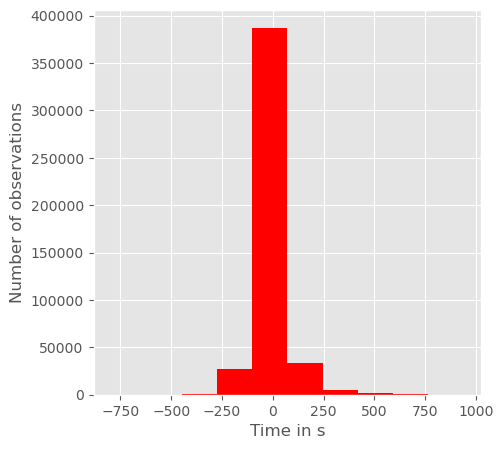

In [131]:
results=pd.DataFrame(zip(y_test, y_pred, y_test-y_pred), columns = ['y_test', 'y_pred', 'error'])
results.head()
plt.figure(figsize=(5,5))
results['error'].hist(color='red')
plt.xlabel("Time in s")
plt.ylabel("Number of observations")
plt.savefig("Results_rf_regression_error_base.png")
plt.show()
plt.savefig("Results_rf_regression_error_base.png")

<Figure size 640x480 with 0 Axes>

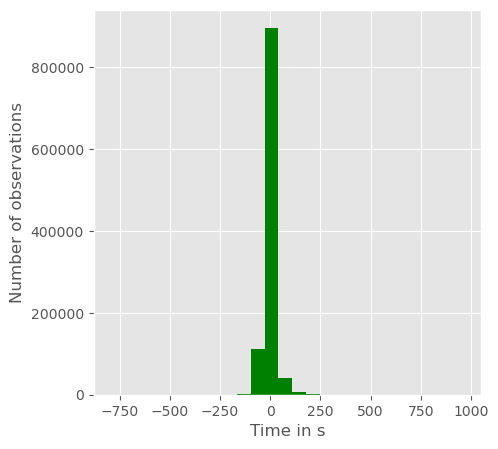

In [133]:
results=pd.DataFrame(zip(y_train, y_train_pred, y_train-y_train_pred), columns = ['y_train', 'y_train_pred', 'error_train'])
results.head()
plt.figure(figsize=(5,5))
results['error_train'].hist(color='green')
plt.xlim(-880,1050)
plt.xlabel("Time in s")
plt.ylabel("Number of observations")
plt.savefig("Results_rf_regression_error_base.png")
plt.show()
plt.savefig("Results_rf_regression_error_base.png")

<Figure size 640x480 with 0 Axes>

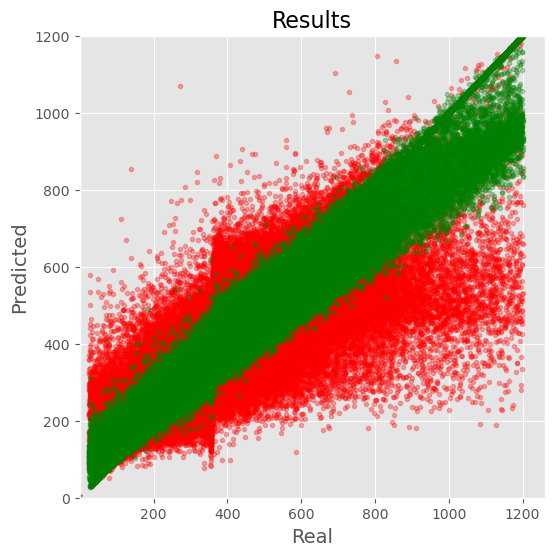

In [135]:
results=pd.DataFrame(zip(y_test, y_pred, y_test-y_pred), columns = ['y_test', 'y_pred', 'error'])
plt.figure(figsize=(6,6))
x=np.linspace(0,5,5)
plt.plot(results['y_test'], results['y_pred'], 'r.', alpha=0.3)
results=pd.DataFrame(zip(y_train, y_train_pred, y_train-y_train_pred), columns = ['y_train', 'y_train_pred', 'error_train'])
plt.plot(results['y_train'], results['y_train_pred'], 'g.', alpha=0.3)
plt.plot(x, x, 'r-')
plt.xlim(0.1200)
plt.ylim(0,1200)
plt.title("Results", fontsize=16)
plt.xlabel("Real", fontsize=14)
plt.ylabel("Predicted", fontsize=14)
plt.show(plt)
plt.savefig("Results_rf_regression_traintest_base.png")

In [254]:
rf_regressor = RandomForestRegressor()
n_estimators=[]
train_mse=[]
test_mse=[]
for n in range(1, 550, 100):
    rf_regressor.n_estimators = n
    rf_regressor.fit(Xx_train, y_train)
    y_train_pred=rf_regressor.predict(Xx_train)
    y_pred=rf_regressor.predict(Xx_test)
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test=mean_squared_error(y_test, y_pred)
    n_estimators.append(n)
    train_mse.append(mse_train)
    test_mse.append(mse_test)

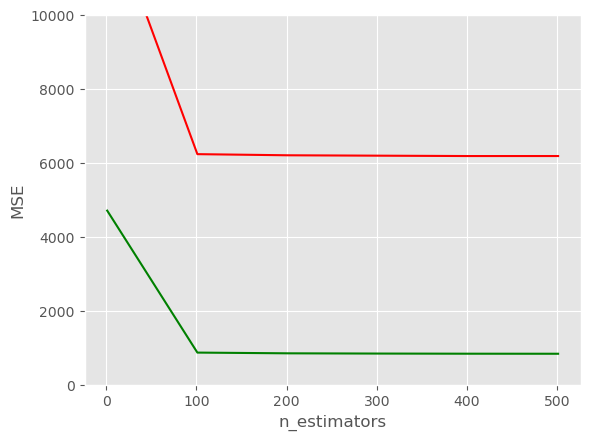

In [255]:
sns.lineplot(x=n_estimators, y=train_mse, color='green')
sns.lineplot(x=n_estimators, y=test_mse, color='red')
plt.xlabel("n_estimators")
plt.ylabel("MSE")
plt.ylim(0, 10000)
plt.show(sns)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid= {
    'n_estimators': [100, 300],
    'max_depth': [10, 20],
    'min_samples_split': [5, 20],
    'min_samples_leaf': [2, 6]
}

grid_search = GridSearchCV(estimator = rf_regressor, param_grid = param_grid, cv=3, n_jobs=1, verbose = 2, error_score='raise', refit=True)
grid_search.fit(Xx_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-validation Score: {grid_search.best_score_}")

In [ ]:
rf_tuned=grid_search.best_estimator_
y_pred_tuned=rf_tuned.predict(Xx_test)
mean_squared_error(y_test, y_pred_tuned)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
y_train_pred_tuned = rf_tuned.predict(Xx_train)
mae_train_tuned = mean_absolute_error(y_train, y_train_pred_tuned)
mse_train_tuned = mean_squared_error(y_train, y_train_pred_tuned)
rmse_train_tuned = np.sqrt(mse_train)
r2_train_tuned = r2_score(y_train, y_train_pred_tuned)

print("Train Set Performance (best estimator model):")
print(f"Mean Absolute Error (MAE): {mae_train_tuned}")
print(f"Mean Squared Error (MSE): {mse_train_tuned}")
print(f"Root Mean Squared Error (RMSE): {rmse_train_tuned}")
print(f"R²: {r2_train_tuned}")

In [ ]:
print("Train Set Performance (best estimator model):")
print(f"Mean Absolute Error (MAE): {mae_train_tuned}")
print(f"Mean Squared Error (MSE): {mse_train_tuned}")
print(f"Root Mean Squared Error (RMSE): {rmse_train_tuned}")
print(f"R²: {r2_train_tuned}")

In [ ]:
mse2= mean_squared_error(y_test, y_pred_tuned)
rmse2=np.sqrt(mse2)
r22 = r2_score(y_test, y_pred_tuned)
mae2 = mean_absolute_error(y_test, y_pred_tuned)
print("Test Set Performance (best estimator model): ")
print("Mean squared error:", mse2)
print("Root mean squared error:", rmse2)
print("R2 score:", r22)
print("Mean absolute error:", mae2)

In [ ]:
print("Test Set Performance (best estimator model): ")
print("Mean squared error:", mse2)
print("Root mean squared error:", rmse2)
print("R2 score:", r22)
print("Mean absolute error:", mae2)

In [ ]:
accuracy_score(y_test, y_pred_tuned)
recall_score(y_test, y_pred_tuned)
precision_score(y_test, y_pred_tuned)
mean_squared_error(y_test, y_pred_tuned)

In [ ]:
results=pd.DataFrame(zip(y_test, y_pred_tuned, y_test-y_pred_tuned), columns = ['y_test', 'y_pred_tuned', 'error'])
results.head()
plt.figure(figsize=(5,5))
results['error'].hist()
plt.savefig("Results_rf_regression_error_tuned.png")
plt.show()


In [ ]:
plt.figure(figsize=(6,6))
x=np.linspace(0,5,5)
plt.plot(results['y_test'], results['y_pred_tuned'], 'r.')
plt.plot(x, x, 'r-')
plt.xlim(20.1200)
plt.ylim(20,1200)
plt.title("Results", fontsize=16)
plt.xlabel("Real", fontsize=14)
plt.ylabel("Predicted", fontsize=14)
plt.savefig("Results_rf_regression_tuned.png")
plt.show(plt)

In [156]:
rf_regressor3 = RandomForestRegressor(n_estimators=500, max_depth=20, min_samples_split=4, min_samples_leaf=6, random_state=42)
rf_regressor3.fit(Xx_train, y_train)
y_pred3=rf_regressor3.predict(Xx_test)
mse3= mean_squared_error(y_test, y_pred3)
rmse3=np.sqrt(mse)
r23 = r2_score(y_test, y_pred3)
mae3 = mean_absolute_error(y_test, y_pred3)
print("Test Set Performance:")
print("Mean squared error:", mse3)
print("Root mean squared error:", rmse3)
print("R2 score:", r23)
print("Mean absolute error:", mae3)

Test Set Performance:
Mean squared error: 6205.6593792777485
Root mean squared error: 78.75115784854539
R2 score: 0.7301233002544606
Mean absolute error: 43.980298028699586


In [157]:
print("Test Set Performance: Tuned Model (n_estimators=500, ,min_samples_split=4):")
print("Mean squared error:", mse3)
print("Root mean squared error:", rmse3)
print("R2 score:", r23)
print("Mean absolute error:", mae3)

Test Set Performance: Tuned Model (n_estimators=500, ,min_samples_split=4):
Mean squared error: 6205.6593792777485
Root mean squared error: 78.75115784854539
R2 score: 0.7301233002544606
Mean absolute error: 43.980298028699586


In [158]:
y_train_pred3 = rf_regressor3.predict(Xx_train)
mae_train3 = mean_absolute_error(y_train, y_train_pred3)
mse_train3 = mean_squared_error(y_train, y_train_pred3)
rmse_train3 = np.sqrt(mse_train3)
r2_train3 = r2_score(y_train, y_train_pred3)

print("Train Set Performance: Tuned Model (n_estimators=500, ,min_samples_split=4):")
print(f"Mean Absolute Error (MAE): {mae_train3}")
print(f"Mean Squared Error (MSE): {mse_train3}")
print(f"Root Mean Squared Error (RMSE): {rmse_train3}")
print(f"R²: {r2_train3}")

Train Set Performance: Tuned Model (n_estimators=500, ,min_samples_split=4):
Mean Absolute Error (MAE): 36.7790821933057
Mean Squared Error (MSE): 4311.135571461393
Root Mean Squared Error (RMSE): 65.65923827963124
R²: 0.8117655636243957


In [164]:
print("Train Set Performance: Tuned Model (n_estimators=500, ,min_samples_split=4):")
print(f"Mean Absolute Error (MAE): {mae_train3}")
print(f"Mean Squared Error (MSE): {mse_train3}")
print(f"Root Mean Squared Error (RMSE): {rmse_train3}")
print(f"R²: {r2_train3}")

Train Set Performance: Tuned Model (n_estimators=500, ,min_samples_split=4):
Mean Absolute Error (MAE): 36.7790821933057
Mean Squared Error (MSE): 4311.135571461393
Root Mean Squared Error (RMSE): 65.65923827963124
R²: 0.8117655636243957


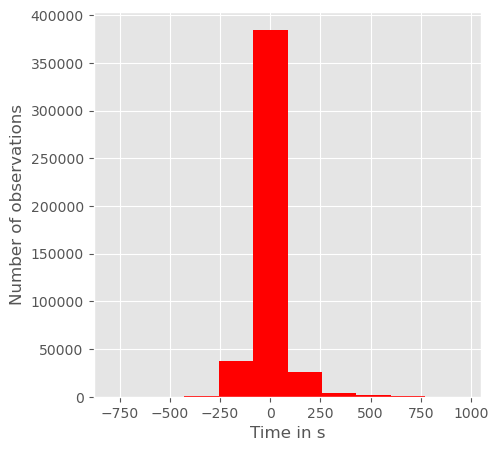

In [166]:
results3=pd.DataFrame(zip(y_test, y_pred3, y_test-y_pred3), columns = ['y_test', 'y_pred3', 'error3'])
results3.head()
plt.figure(figsize=(5,5))
results3['error3'].hist(color='red')
plt.xlim(-880,1050)
plt.ylabel("Number of observations")
plt.xlabel("Time in s")
plt.savefig("Results_rf_regression3.png")
plt.show()
plt.savefig("Results_rf_regression3.png")

<Figure size 640x480 with 0 Axes>

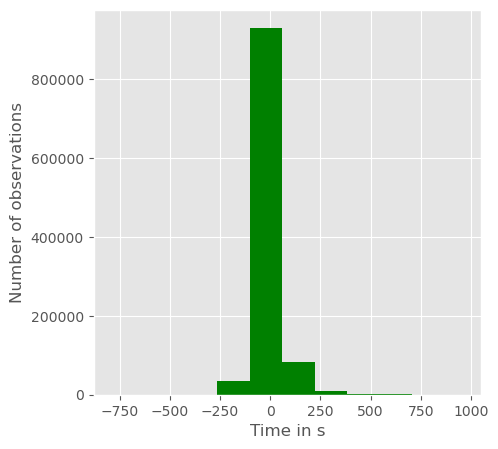

In [168]:
results3=pd.DataFrame(zip(y_train, y_train_pred3, y_train-y_train_pred3), columns = ['y_train', 'y_train_pred3', 'error_train3'])
results3.head()
plt.figure(figsize=(5,5))
results3['error_train3'].hist(color='green')
plt.xlim(-880,1050)
plt.ylabel("Number of observations")
plt.xlabel("Time in s")
plt.savefig("Results_rf__train_regression3.png")
plt.show()
plt.savefig("Results_rf__train_regression3.png")

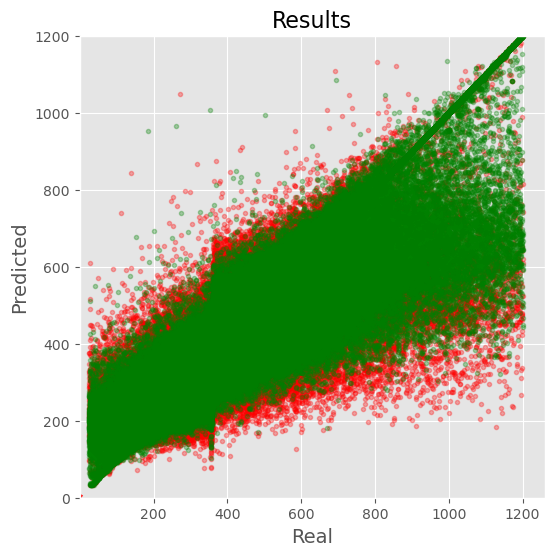

In [218]:
plt.figure(figsize=(6,6))
x=np.linspace(0,5,5)
results3=pd.DataFrame(zip(y_test, y_pred3, y_test-y_pred3), columns = ['y_test', 'y_pred3', 'error3'])
plt.plot(results3['y_test'], results3['y_pred3'], 'r.', alpha=0.3)
results3=pd.DataFrame(zip(y_train, y_train_pred3, y_train-y_train_pred3), columns = ['y_train', 'y_train_pred3', 'error_train3'])
plt.plot(results3['y_train'], results3['y_train_pred3'], 'g.', alpha=0.3)
plt.plot(x, x, 'r-')
plt.xlim(0.1200)
plt.ylim(00,1200)
plt.title("Results", fontsize=16)
plt.xlabel("Real", fontsize=14)
plt.ylabel("Predicted", fontsize=14)
plt.show(plt)
plt.savefig("Results_rf_regressio3n_traintest.png")

In [250]:
rf_regressor_leaf = RandomForestRegressor()
min_samples_leaf=[]
train_mse3=[]
test_mse3=[]
for n in range(1, 9, 2):
    rf_regressor_leaf.min_samples_leaf = n
    rf_regressor_leaf.fit(Xx_train, y_train)
    y_train_pred3=rf_regressor_leaf.predict(Xx_train)
    y_pred3=rf_regressor_leaf.predict(Xx_test)
    mse_train3 = mean_squared_error(y_train, y_train_pred3)
    mse_test3=mean_squared_error(y_test, y_pred3)
    min_samples_leaf.append(n)
    train_mse3.append(mse_train3)
    test_mse3.append(mse_test3)

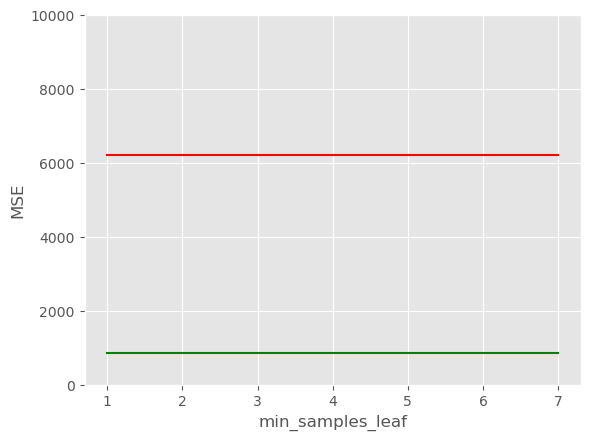

In [251]:
sns.lineplot(x=min_samples_leaf, y=mse_train, color='green')
sns.lineplot(x=min_samples_leaf, y=mse_test, color='red')
plt.xlabel("min_samples_leaf")
plt.ylabel("MSE")
plt.ylim(0,10000)
plt.show(sns)

In [ ]:
rf_regressor_leaf4 = RandomForestRegressor(n_estimators=500, max_depth=20)
min_samples_leaf4=[]
train_mse4=[]
test_mse4=[]
for n in range(1, 9, 2):
    rf_regressor_leaf4.min_samples_leaf = n
    rf_regressor_leaf4.fit(Xx_train, y_train)
    y_train_pred4=rf_regressor_leaf4.predict(Xx_train)
    y_pred4=rf_regressor_leaf4.predict(Xx_test)
    mse_train4 = mean_squared_error(y_train, y_train_pred4)
    mse_test4=mean_squared_error(y_test, y_pred4)
    min_samples_leaf4.append(n)
    train_mse4.append(mse_train4)
    test_mse4.append(mse_test4)

In [ ]:
sns.lineplot(x=min_samples_leaf4, y=mse_train4, color='green')
sns.lineplot(x=min_samples_leaf4, y=mse_test4, color='red')
plt.xlabel("min_samples_leaf")
plt.ylabel("MSE")
plt.ylim(0,10000)
plt.show(sns)

In [ ]:
rf_regressor_split5 = RandomForestRegressor(n_estimators=500, max_depth=20, min_samples_leaf=6)
min_samples_split5=[]
train_mse5=[]
test_mse5=[]
for n in range(2, 15, 2):
    rf_regressor_split5.min_samples_split = n
    rf_regressor_split5.fit(Xx_train, y_train)
    y_train_pred5=rf_regressor_split5.predict(Xx_train)
    y_pred5=rf_regressor_split5.predict(Xx_test)
    mse_train5 = mean_squared_error(y_train, y_train_pred5)
    mse_test5=mean_squared_error(y_test, y_pred5)
    min_samples_split5.append(n)
    train_mse5.append(mse_train5)
    test_mse5.append(mse_test5)

In [172]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [196]:
import shap
Xx_test_sample = Xx_test.sample(n=1500, random_state=42)

PermutationExplainer explainer: 1501it [43:02,  1.73s/it]                                                              
C:\Users\Thesa\AppData\Local\Temp\ipykernel_7796\4093216893.py:3: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



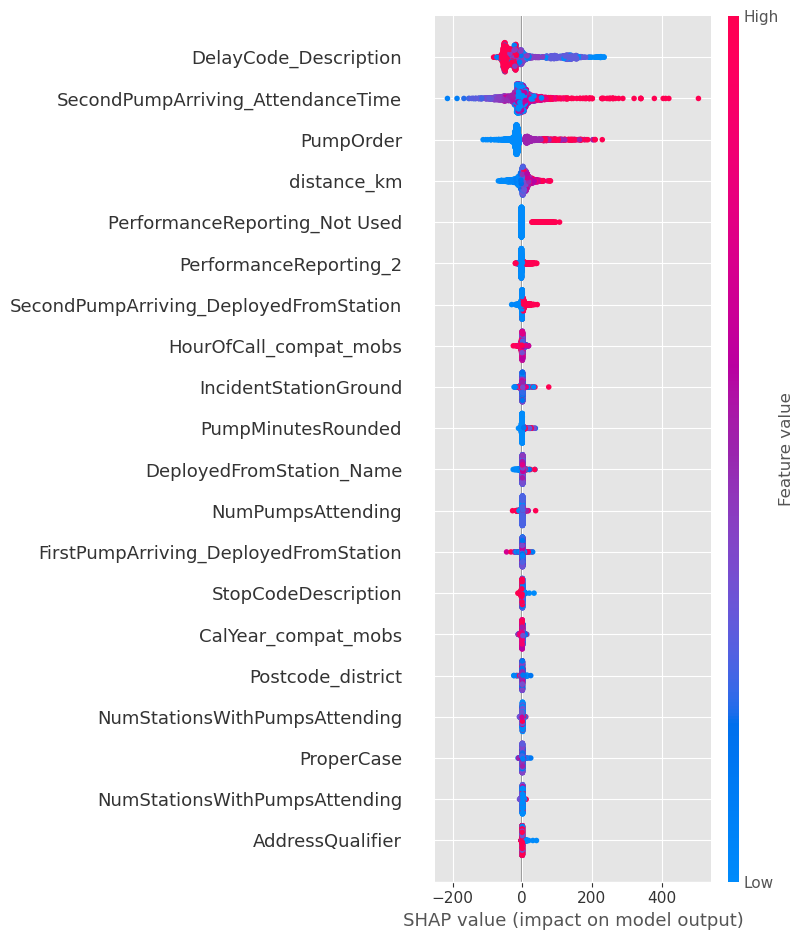

In [198]:
explainer = shap.Explainer(rf_regressor3.predict, Xx_test_sample)
shap_values_sample = explainer.shap_values(Xx_test_sample)
shap.summary_plot(shap_values_sample, Xx_test_sample)

C:\Users\Thesa\AppData\Local\Temp\ipykernel_7796\3904241285.py:1: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



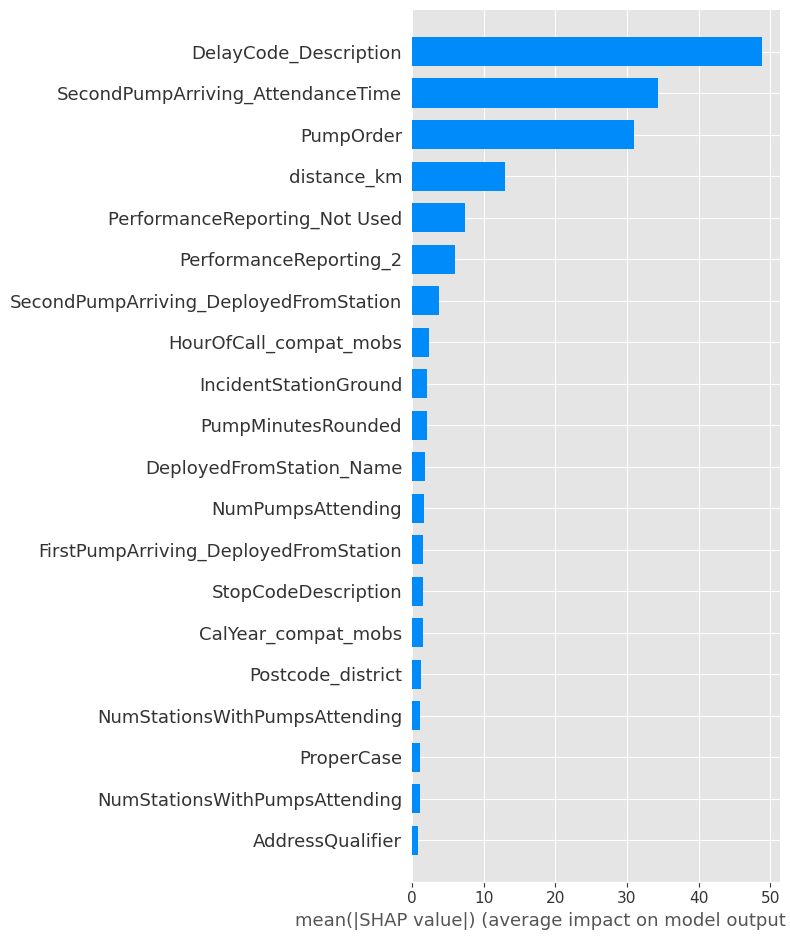

In [200]:
shap.summary_plot(shap_values_sample, Xx_test_sample, plot_type="bar")
plt.savefig("shap_bar_rfregressor3.png")

In [ ]:
Xxx_train=Xx_train.drop(['DeployedFromStation_Name', 'SecondPumpArriving_DeployedFromStation' ], axis=1)
Xxx_test=Xx_test.drop(['DeployedFromStation_Name', 'SecondPumpArriving_DeployedFromStation' ], axis=1)

In [ ]:
Xxx_train.to_csv('Xxx_train.csv', sep=';', index=False)

In [ ]:
Xxx_test.to_csv('Xxx_test.csv', sep=';', index=False)

In [ ]:
rf_regressor4 = RandomForestRegressor(n_estimators=500, max_depth=20, min_samples_split=5, min_samples_leaf=6, random_state=42)
rf_regressor4.fit(Xxx_train, y_train)
y_pred4=rf_regressor4.predict(Xxx_test)
mse4= mean_squared_error(y_test, y_pred4)
rmse4=np.sqrt(mse4)
r24 = r2_score(y_test, y_pred4)
print("Mean squared error:", mse4)
print("\nn")
print("Root mean squared error:", rmse4)
print("\nn")
print("R2 score:", r24)

In [ ]:
results4=pd.DataFrame(zip(y_test, y_pred4, y_test-y_pred4), columns = ['y_test', 'y_pred4', 'error'])
results4.head()
plt.figure(figsize=(5,5))
results4['error'].hist()
plt.savefig("Results_rf_regression_error4.png")
plt.show()

In [ ]:
plt.figure(figsize=(6,6))
x=np.linspace(0,5,5)
plt.plot(results4['y_test'], results4['y_pred4'], 'b.')
plt.plot(x, x, 'r-')
plt.xlim(25.1200)
plt.ylim(25,1200)
plt.title("Results", fontsize=16)
plt.xlabel("Real", fontsize=14)
plt.ylabel("Predicted", fontsize=14)
plt.savefig("Results_rf_regression4.png")
plt.show(plt)

In [ ]:
pip install xgboost

In [ ]:
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error
model_lr = LinearRegression()
model_lr.fit(Xx_train, y_train)

In [ ]:
print("score train:", model_lr.score(Xx_train, y_train))
print("score test:", model_lr.score(Xx_test, y_test))

In [ ]:
pred = model_lr.predict(Xx_train)
pred_test=model_lr.predict(Xx_test)

In [ ]:
print("RMSE Train:", np.sqrt(mean_squared_error(y_train, pred)))
print("RMSE Test:", np.sqrt(mean_squared_error(y_test, pred_test)))

In [ ]:
from sklearn.linear_model import ElasticNetCV
model_en= ElasticNetCV (alphas=None, l1_ratio=0.5)
model_en.fit(Xx_train, y_train)

In [ ]:
print("score train:", model_en.score(Xx_train, y_train))
print("score test:", model_en.score(Xx_test, y_test))

In [ ]:
pred_en = model_en.predict(Xx_train)
pred_test_en=model_en.predict(Xx_test)

In [ ]:
print("RMSE Train:", np.sqrt(mean_squared_error(y_train, pred_en)))
print("RMSE Test:", np.sqrt(mean_squared_error(y_test, pred_test_en)))

In [ ]:
from sklearn.linear_model import ElasticNetCV
model2_en= ElasticNetCV (cv=12, l1_ratio=(0.1, 0.25, 0.5, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99),
                         alphas=(0.00001, 0.00005, 0.0001, 0.00015, 0.0002, 0.005, 0.01, 0.02, 0.025, 0.05, 0.1, 0.25, 0.5, 0.8, 0.85, 0.9, 1.0), max_iter=10000000, random_state=42)
model2_en.fit(Xx_train, y_train)

print("Best alpha:", model2_en.alphas)
print("Best L1 ratio:", model2_en.l1_ratio)

In [ ]:
print("score train:", model2_en.score(Xx_train, y_train))
print("score test:", model2_en.score(Xx_test, y_test))

In [ ]:
pred2_en = model2_en.predict(Xx_train)
pred2_test_en=model2_en.predict(Xx_test)

In [ ]:
print("RMSE Train:", np.sqrt(mean_squared_error(y_train, pred2_en)))
print("RMSE Test:", np.sqrt(mean_squared_error(y_test, pred2_test_en)))

In [ ]:
pip install xgboost